Connected to nncf-py (Python 3.10.16)

In [ ]:
model_fp = "/home/nlyaly/projects/nncf/tests/post_training/tmp/fp32_models/TinyLlama__TinyLlama_v1.1"
model_int = "/home/nlyaly/projects/nncf/tests/post_training/tmp/tinyllama_int8_data_free/TORCH"
tokenizer = "TinyLlama/TinyLlama-1.1B"
n_samples = 10

In [ ]:
#!/usr/bin/env python3
# Copyright (c) 2025 Intel Corporation
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#      http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

"""
Example script demonstrating how to use the draw_activations_2 function
for comparing floating point and quantized model activations with histograms.
"""

import os
import re
from typing import Any, Optional

import numpy as np
import openvino as ov
from datasets import load_dataset
from transformers import AutoTokenizer

from nncf.common.graph.transformations.commands import TargetType
from nncf.common.tensor_statistics.statistic_point import StatisticPoint
from nncf.common.tensor_statistics.statistic_point import StatisticPointsContainer
from nncf.openvino.graph.nncf_graph_builder import GraphConverter
from nncf.openvino.graph.transformations.commands import OVTargetPoint
from nncf.openvino.statistics.aggregator import OVStatisticsAggregator
from nncf.openvino.statistics.collectors import get_raw_stat_collector


def gen_pkv(n_vals, sz, f_size=12):  # opt-125m
    res = {}
    # "?,12,?,64"
    for i in range(n_vals):
        res[f"past_key_values.{i}.value"] = np.zeros((1, f_size, 0, sz))
        res[f"past_key_values.{i}.key"] = np.zeros((1, f_size, 0, sz))

    return res


def gen_pkv_(n_vals, sz):  # redpajama
    res = {}
    # "?,32,?,128"
    for i in range(n_vals):
        res[f"past_key_values.{i}.value"] = np.zeros((1, 32, 0, sz))
        res[f"past_key_values.{i}.key"] = np.zeros((1, 32, 0, sz))

    return res


def transform_fn(data, model, tokenizer):
    tokenized_text = tokenizer(data["text"], return_tensors="np")
    input_ids = tokenized_text["input_ids"]
    attention_mask = tokenized_text["attention_mask"]

    batch_size = input_ids.shape[0]
    input_shapes = {}
    for val in model.model.inputs:
        name = val.any_name
        shape = list(val.partial_shape.get_min_shape())
        shape[0] = batch_size
        input_shapes[name] = shape

    inputs = {}
    inputs["input_ids"] = input_ids
    inputs["attention_mask"] = tokenized_text["attention_mask"]
    position_ids = np.cumsum(attention_mask, axis=1) - 1
    position_ids[attention_mask == 0] = 1

    # The magic forms KV cache as model inputs
    batch_size = input_ids.shape[0]
    for input_name in model.key_value_input_names:
        model_inputs = model.model.input(input_name)
        shape = model_inputs.get_partial_shape()
        shape[0] = batch_size
        if shape[2].is_dynamic:
            shape[2] = 0
        else:
            shape[1] = 0
        inputs[input_name] = ov.Tensor(model_inputs.get_element_type(), shape.get_shape())

    if "beam_idx" in input_shapes:
        inputs["beam_idx"] = np.arange(batch_size, dtype=int)

    inputs["position_ids"] = position_ids
    return inputs


def get_noop_statistic_collector(
    num_samples: int, channel_axis: int, window_size: Optional[int] = None, inplace: bool = True
):
    """
    Raw statistic collector builder.

    :param num_samples: Maximum number of samples to collect.
    :param channel_axis: Channel axis to use during reduction phase.
    :param window_size: Number of samples from the end of the list of collected samples to aggregate.
        Aggregates all available collected statistics in case parameter is None.
    :param inplace: Whether the mean reducer should be calculated inplace or out of place.
    :return: Mean statistic collector.
    """
    from nncf.experimental.common.tensor_statistics.collectors import NoopAggregator
    from nncf.experimental.common.tensor_statistics.collectors import RawReducer
    from nncf.experimental.common.tensor_statistics.collectors import TensorCollector

    reducer = RawReducer()
    aggregate_mean = NoopAggregator(num_samples)

    collector = TensorCollector()
    collector.register_statistic_branch("MEAN_STAT", reducer, aggregate_mean)
    return collector


def get_statistic_points(model, graph, nodes, subset_size) -> StatisticPointsContainer:
    statistic_container = StatisticPointsContainer()
    OUTPUT_PORT_OF_NODE = 0
    INPUT_PORT_OF_NODE = 0

    # Collection of statistics after/before layers.
    for node in nodes:
        node_name = node.node_name
        channel_axis = node.metatype.output_channel_axis
        if channel_axis is None:
            channel_axis = -1

        # For layers with weights, there is only one output port - 0.
        statistic_point_out = OVTargetPoint(TargetType.POST_LAYER_OPERATION, node_name, port_id=OUTPUT_PORT_OF_NODE)
        stat_collector_out = get_raw_stat_collector(num_samples=subset_size)
        statistic_container.add_statistic_point(
            StatisticPoint(target_point=statistic_point_out, tensor_collector=stat_collector_out, algorithm="collect")
        )

        # For layers with weights, there is only one output port - 0.
        statistic_point_in = OVTargetPoint(TargetType.PRE_LAYER_OPERATION, node_name, port_id=INPUT_PORT_OF_NODE)
        stat_collector_in = get_raw_stat_collector(num_samples=subset_size)
        statistic_container.add_statistic_point(
            StatisticPoint(target_point=statistic_point_in, tensor_collector=stat_collector_in, algorithm="collect")
        )

    return statistic_container


def get_input_statistic_points(model, graph, nodes, subset_size) -> StatisticPointsContainer:
    statistic_container = StatisticPointsContainer()
    INPUT_PORT_OF_NODE = 1
    OUTPUT_PORT_OF_NODE = 0

    # Collection of statistics after/before layers.
    for node in nodes:
        node_name = node.node_name
        channel_axis = node.metatype.output_channel_axis
        if channel_axis is None:
            channel_axis = -1

        # For layers with weights, there is only one output port - 0.
        statistic_point_in = OVTargetPoint(TargetType.PRE_LAYER_OPERATION, node_name, port_id=INPUT_PORT_OF_NODE)
        stat_collector_in = get_noop_statistic_collector(
            channel_axis=channel_axis, num_samples=subset_size, inplace=False
        )
        statistic_container.add_statistic_point(
            StatisticPoint(target_point=statistic_point_in, tensor_collector=stat_collector_in, algorithm="collect")
        )

        # For layers with weights, there is only one output port - 0.
        statistic_point_out = OVTargetPoint(TargetType.POST_LAYER_OPERATION, node_name, port_id=OUTPUT_PORT_OF_NODE)
        stat_collector_out = get_noop_statistic_collector(
            channel_axis=channel_axis, num_samples=subset_size, inplace=False
        )
        statistic_container.add_statistic_point(
            StatisticPoint(target_point=statistic_point_out, tensor_collector=stat_collector_out, algorithm="collect")
        )

    return statistic_container


def collect_activations(model: "ov.Model", dataset: Any, regexp: re.Pattern, subset_size=4):
    """
    Collect activations from OpenVINO model using NNCF statistics collector.

    Args:
        model: OpenVINO model
        dataset: NNCF dataset for calibration
        regexp: Regular expression pattern to match layer names
        subset_size: Number of samples to process

    Returns:
        Dictionary with layer outputs for matched operations
    """

    # Find target operations
    target_ops = [op for op in model.get_ordered_ops() if bool(regexp.search(op.get_friendly_name()))]

    if len(target_ops) == 0:
        print("No operations found matching pattern:", regexp.pattern)
        return {}

    print(f"Found {len(target_ops)} target operations matching pattern")

    # Create NNCF graph
    graph = GraphConverter.create_nncf_graph(model)
    statistics_aggregator = OVStatisticsAggregator(dataset)

    node_keys = graph.get_all_node_keys()
    target_names = [val for val in node_keys if bool(regexp.search(val))]
    target_ops = [graph.get_node_by_key(target_name) for target_name in target_names]

    statistic_points = get_statistic_points(model, graph, target_ops, subset_size)
    statistics_aggregator.register_statistic_points(statistic_points)
    statistics_aggregator.collect_statistics(model, graph)

    res = {}
    for k, v in statistics_aggregator.statistic_points.items():
        res[k] = {
            "in": list(v[1].algorithm_to_tensor_collectors["collect"][0].aggregators.values())[0]._container,
            "out": list(v[0].algorithm_to_tensor_collectors["collect"][0].aggregators.values())[0]._container,
        }

    return res


def collect_weights(model: "ov.Model", dataset: Any, regexp: "re.Pattern", subset_size=1):
    """
    Collect weights from OpenVINO model using NNCF statistics collector.

    Args:
        model: OpenVINO model
        dataset: NNCF dataset for calibration
        regexp: Regular expression pattern to match layer names
        subset_size: Number of samples to process

    Returns:
        Dictionary with layer weights for matched operations
    """
    # Find target operations
    target_ops = [op for op in model.get_ordered_ops() if bool(regexp.search(op.get_friendly_name()))]

    if len(target_ops) == 0:
        print("No operations found matching pattern:", regexp.pattern)
        return {}

    graph = GraphConverter.create_nncf_graph(model)
    statistics_aggregator = OVStatisticsAggregator(dataset)

    node_keys = graph.get_all_node_keys()
    target_names = [val for val in node_keys if bool(regexp.search(val))]
    target_ops = [graph.get_node_by_key(target_name) for target_name in target_names]

    statistic_points = get_input_statistic_points(model, graph, target_ops, subset_size)
    statistics_aggregator.register_statistic_points(statistic_points)
    statistics_aggregator.collect_statistics(model, graph)

    res = {}
    for k, v in statistics_aggregator.statistic_points.items():
        res[k] = {
            "in": list(v[0].algorithm_to_tensor_collectors["collect"][0].aggregators.values())[0]._container,
            "out": list(v[1].algorithm_to_tensor_collectors["collect"][0].aggregators.values())[0]._container,
        }

    return res


def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r'__module.model.layers..*\d+.self_attn.v_proj/ov_ext::linear/MatMul',
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        # r"__module.model.embed_tokens/aten::embedding/Gather",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

/home/nlyaly/env/nncf-py/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

Multiple distributions found for package optimum. Picked distribution: optimum


OSError: TinyLlama/TinyLlama-1.1B is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

In [ ]:
tokenizer = "TinyLlama/TinyLlama_v1.1"

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 22 target operations matching pattern


/home/nlyaly/env/nncf-py/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Found 22 target operations matching pattern


REG Name __module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul in
__module.model.layers.0.mlp.down_proj/aten::linear/MatMul
compressed  -97.09368 160.91553
fp32  -97.45829 161.26573


<ipython-input-2-64f5f1350421>:349: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


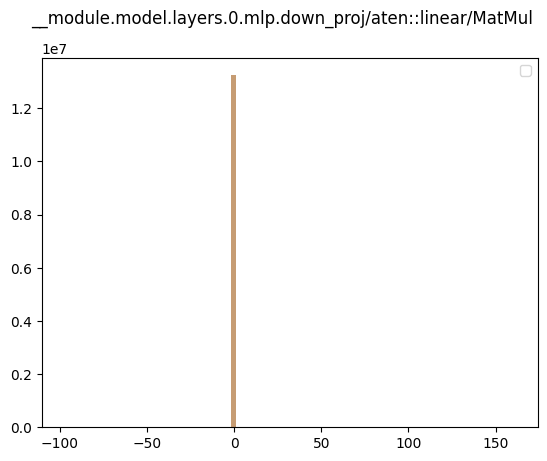

__module.model.layers.1.mlp.down_proj/aten::linear/MatMul
compressed  -10.664949 6.4971247
fp32  -10.60357 6.5329504


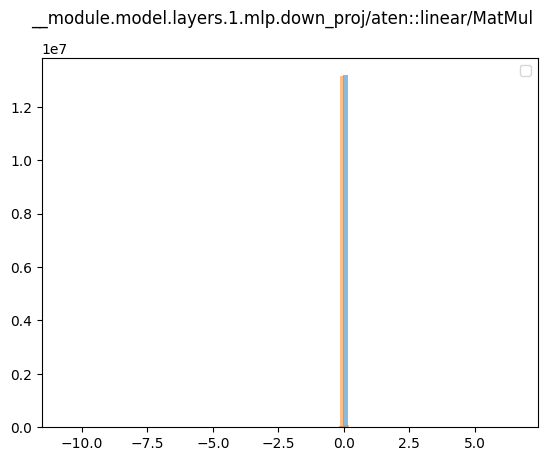

__module.model.layers.2.mlp.down_proj/aten::linear/MatMul
compressed  -0.97614104 1.4614139
fp32  -0.98054796 1.5983243


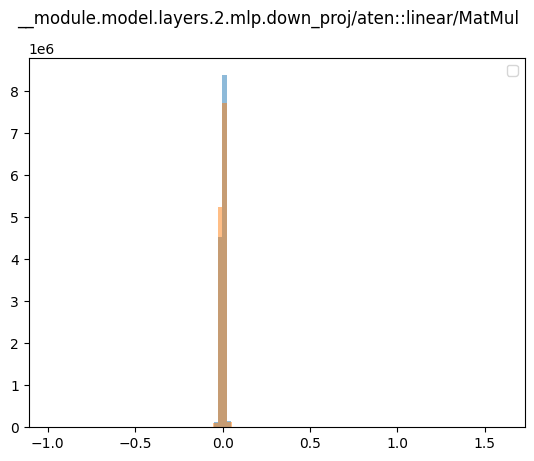

__module.model.layers.3.mlp.down_proj/aten::linear/MatMul
compressed  -1.2524452 1.3031021
fp32  -1.26334 1.3189629


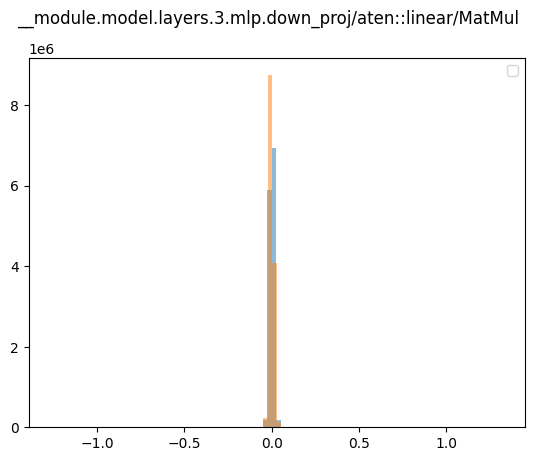

__module.model.layers.4.mlp.down_proj/aten::linear/MatMul
compressed  -0.9780812 1.1453418
fp32  -0.98695093 1.1479772


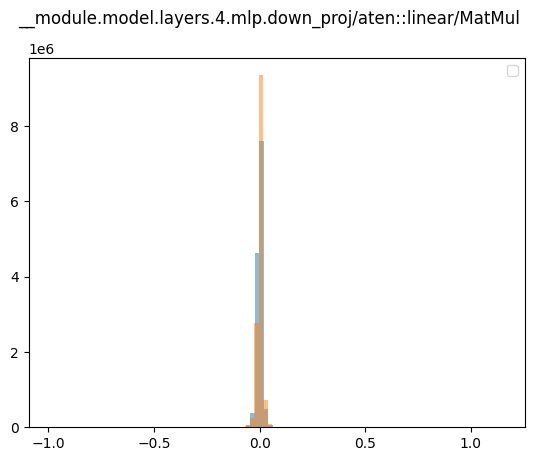

__module.model.layers.5.mlp.down_proj/aten::linear/MatMul
compressed  -1.3967999 1.1984028
fp32  -1.401671 1.1972027


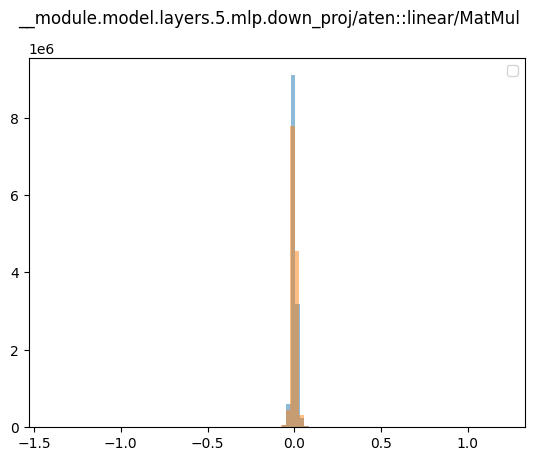

__module.model.layers.6.mlp.down_proj/aten::linear/MatMul
compressed  -1.8136455 1.3324692
fp32  -1.7879211 1.3401906


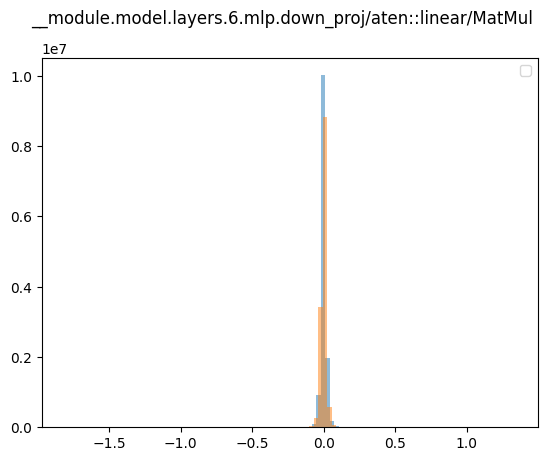

__module.model.layers.7.mlp.down_proj/aten::linear/MatMul
compressed  -1.5152762 6.821211
fp32  -1.5224895 7.041584


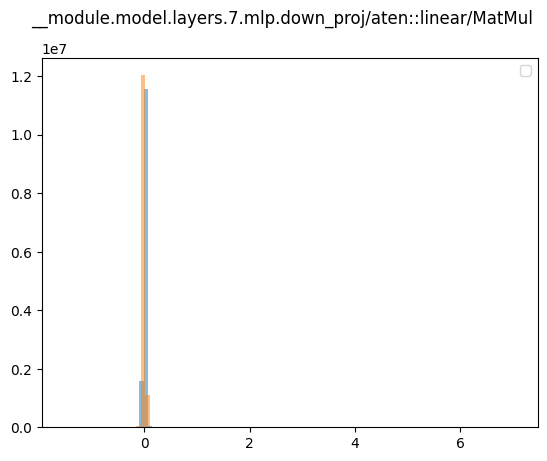

__module.model.layers.8.mlp.down_proj/aten::linear/MatMul
compressed  -1.6777108 2.5076041
fp32  -1.7464732 2.15704


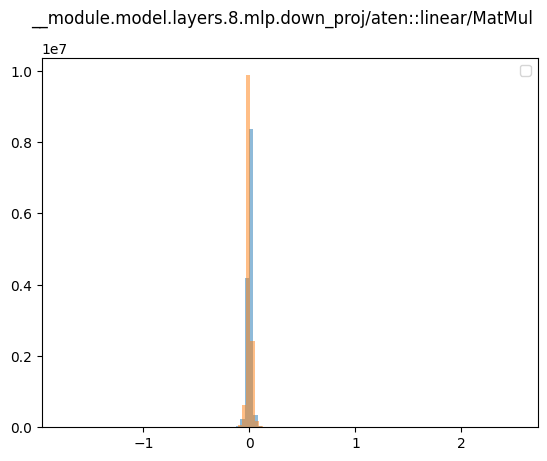

__module.model.layers.9.mlp.down_proj/aten::linear/MatMul
compressed  -3.075603 1.2341598
fp32  -4.1916246 2.183477


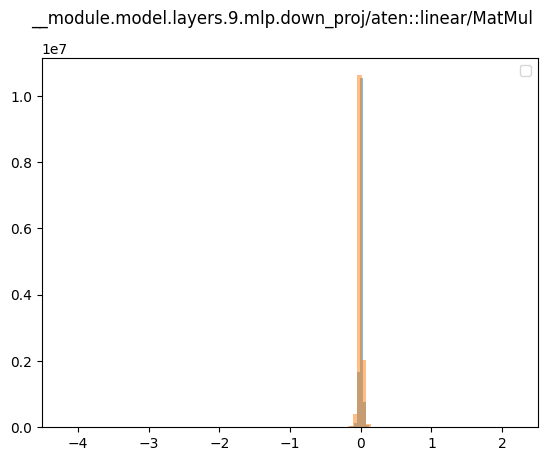

__module.model.layers.10.mlp.down_proj/aten::linear/MatMul
compressed  -2.0421336 5.2184644
fp32  -3.4408185 2.2666535


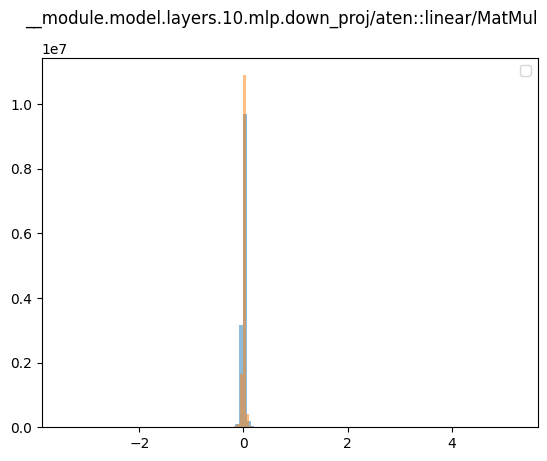

__module.model.layers.11.mlp.down_proj/aten::linear/MatMul
compressed  -2.0823126 2.1082366
fp32  -2.007507 2.3599894


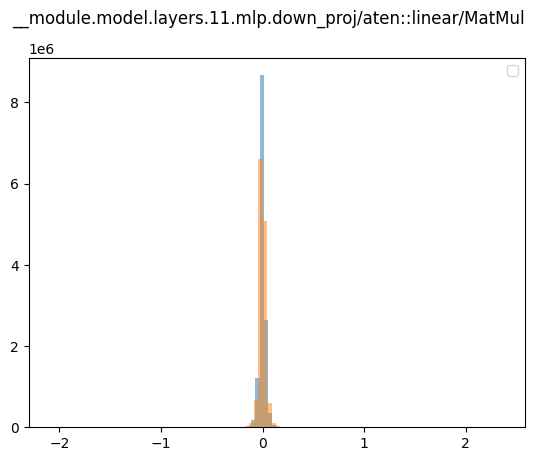

__module.model.layers.12.mlp.down_proj/aten::linear/MatMul
compressed  -4.149282 2.6299396
fp32  -3.9908383 1.6423781


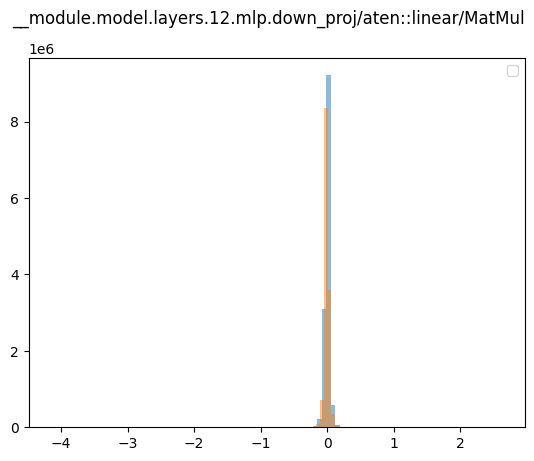

__module.model.layers.13.mlp.down_proj/aten::linear/MatMul
compressed  -2.244259 3.3339245
fp32  -4.1283474 4.3798413


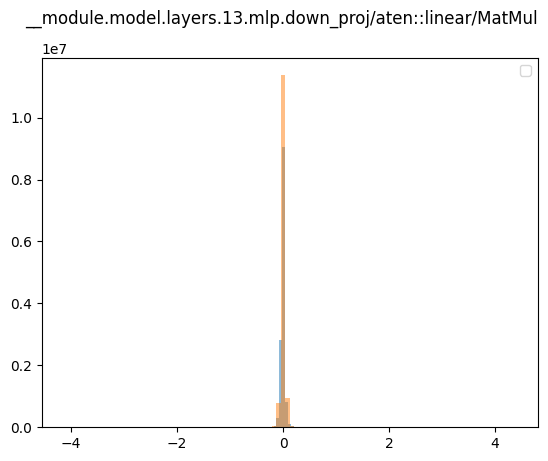

__module.model.layers.14.mlp.down_proj/aten::linear/MatMul
compressed  -4.9597616 4.639678
fp32  -4.71596 3.6561546


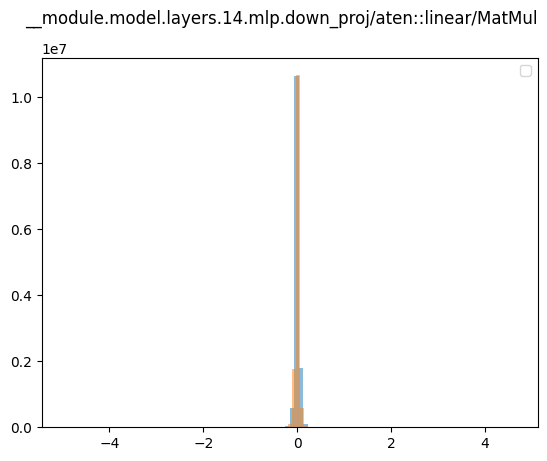

__module.model.layers.15.mlp.down_proj/aten::linear/MatMul
compressed  -7.559886 6.700217
fp32  -6.468946 7.907144


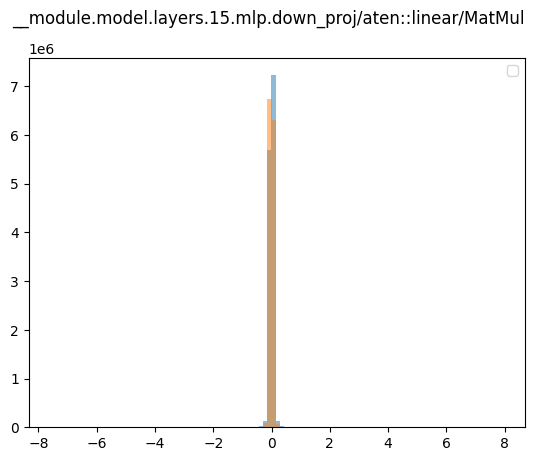

__module.model.layers.16.mlp.down_proj/aten::linear/MatMul
compressed  -8.19541 7.525195
fp32  -6.041764 7.625871


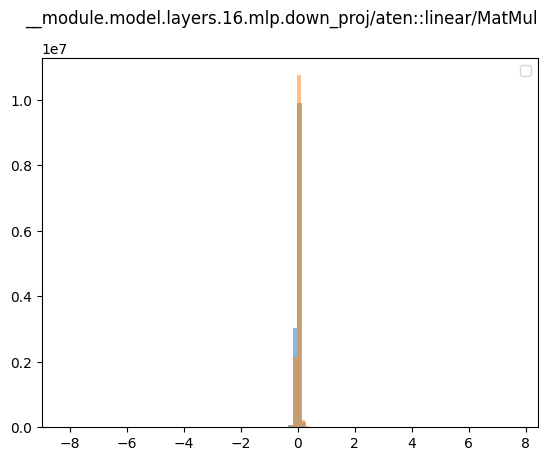

__module.model.layers.17.mlp.down_proj/aten::linear/MatMul
compressed  -7.4131036 6.910467
fp32  -7.2061534 6.977987


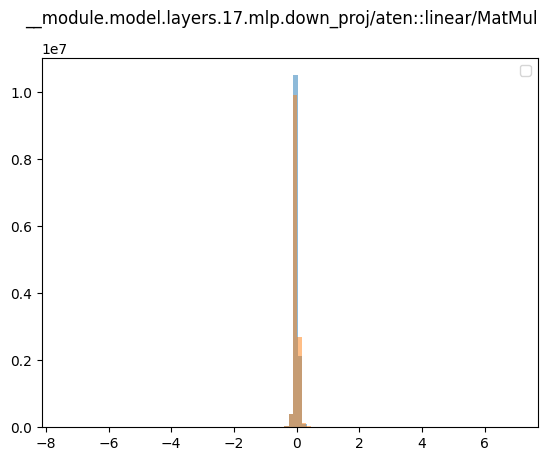

__module.model.layers.18.mlp.down_proj/aten::linear/MatMul
compressed  -8.958774 7.567482
fp32  -5.2913723 7.273148


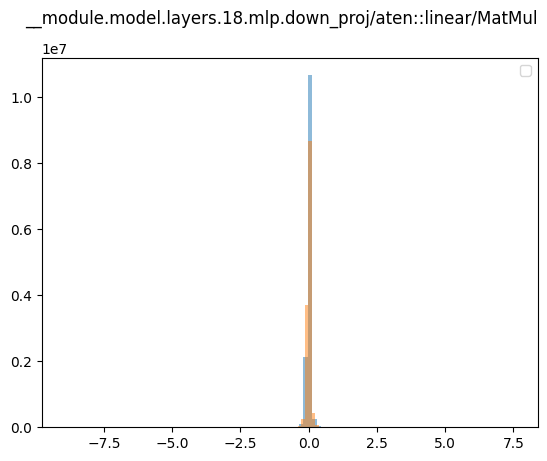

__module.model.layers.19.mlp.down_proj/aten::linear/MatMul
compressed  -9.4002695 125.046906
fp32  -9.695302 123.817604


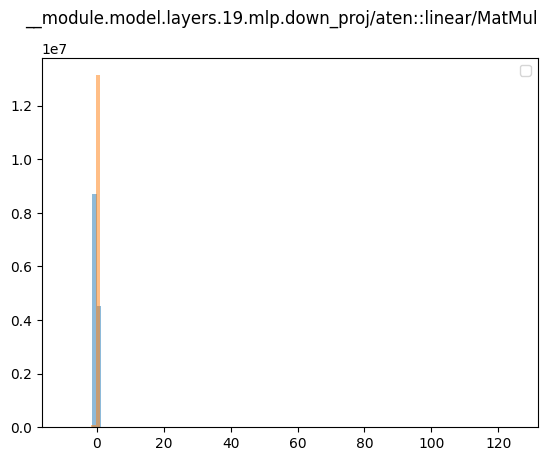

__module.model.layers.20.mlp.down_proj/aten::linear/MatMul
compressed  -11.936077 14.323755
fp32  -11.417531 9.139582


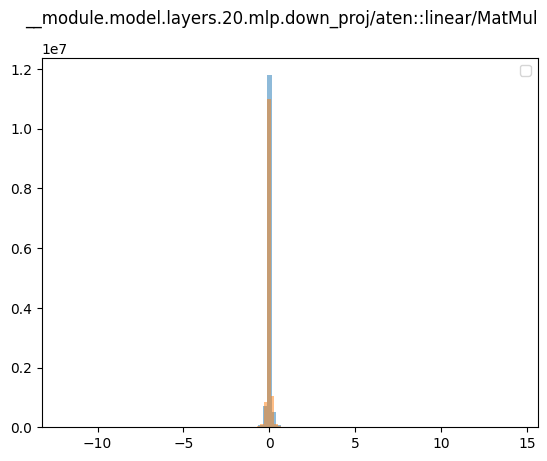

__module.model.layers.21.mlp.down_proj/aten::linear/MatMul
compressed  -106.36025 50.86884
fp32  -105.20638 37.196194


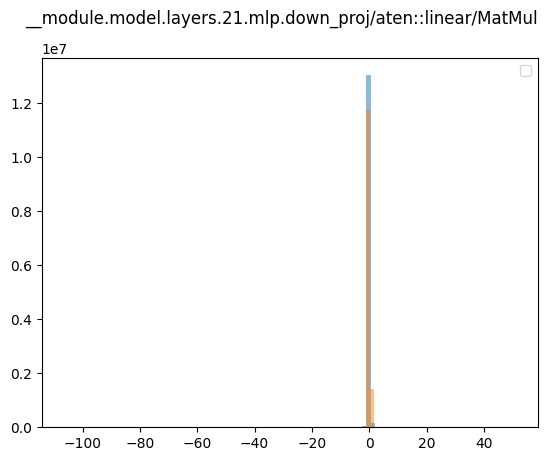

<ipython-input-2-64f5f1350421>:371: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-2-64f5f1350421>:382: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul out
__module.model.layers.0.mlp.down_proj/aten::linear/MatMul
compressed  -166.7331 96.776215
fp32  -166.52237 97.151146


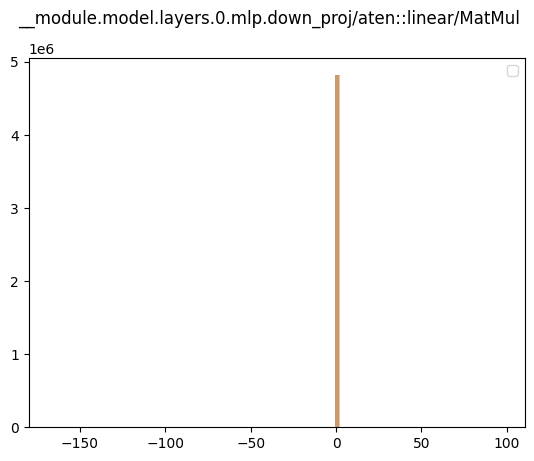

__module.model.layers.1.mlp.down_proj/aten::linear/MatMul
compressed  -15.269519 22.597515
fp32  -15.242815 22.547516


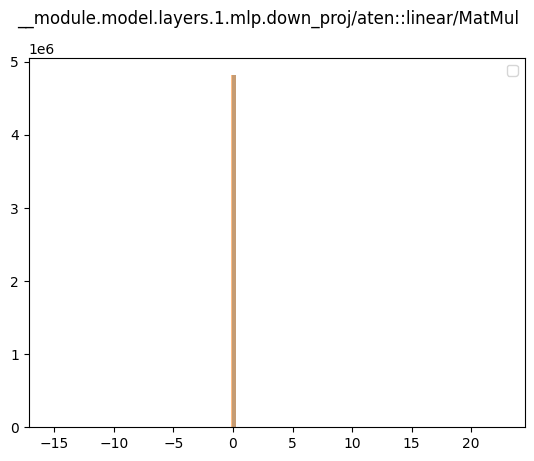

__module.model.layers.2.mlp.down_proj/aten::linear/MatMul
compressed  -0.96045864 0.6646261
fp32  -1.0562836 0.65111256


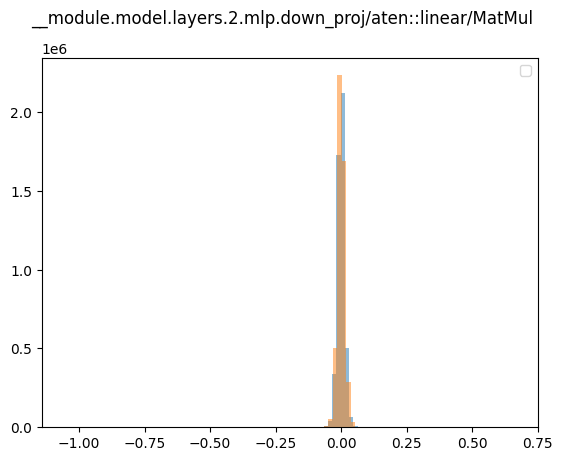

__module.model.layers.3.mlp.down_proj/aten::linear/MatMul
compressed  -0.17253684 0.53509873
fp32  -0.17015783 0.5276194


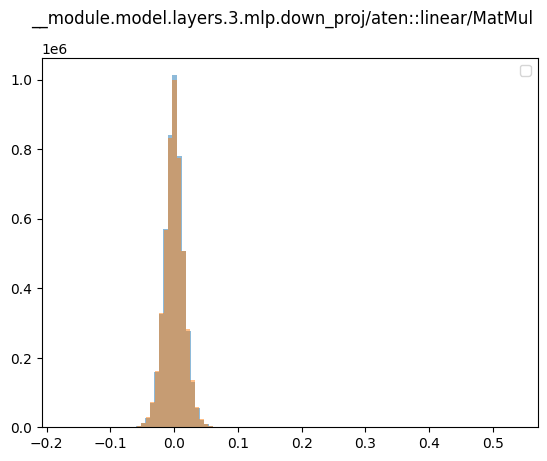

__module.model.layers.4.mlp.down_proj/aten::linear/MatMul
compressed  -0.23792475 0.6152095
fp32  -0.24533877 0.61524594


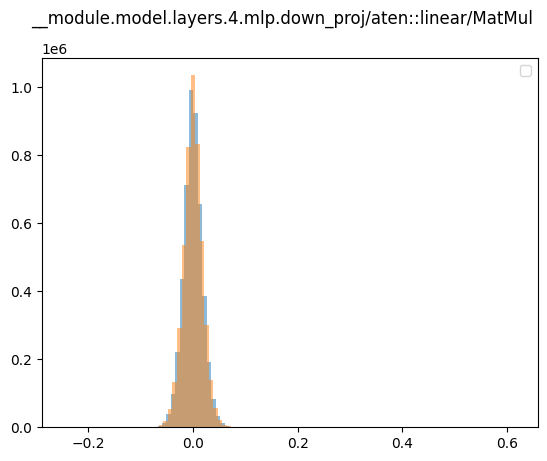

__module.model.layers.5.mlp.down_proj/aten::linear/MatMul
compressed  -0.2572133 0.8018544
fp32  -0.25403988 0.80505747


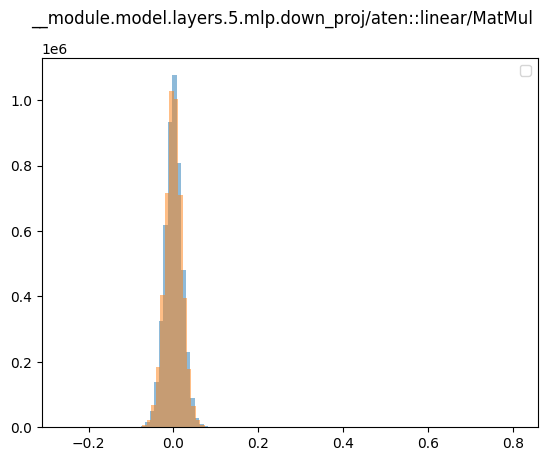

__module.model.layers.6.mlp.down_proj/aten::linear/MatMul
compressed  -0.9946505 2.2660396
fp32  -0.9972433 2.2734718


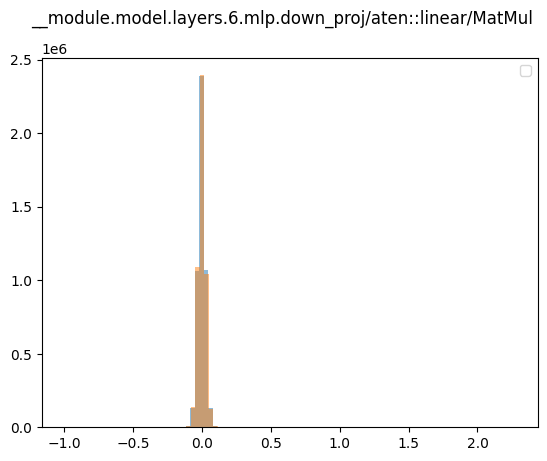

__module.model.layers.7.mlp.down_proj/aten::linear/MatMul
compressed  -4.626007 7.1548686
fp32  -4.4858446 6.928575


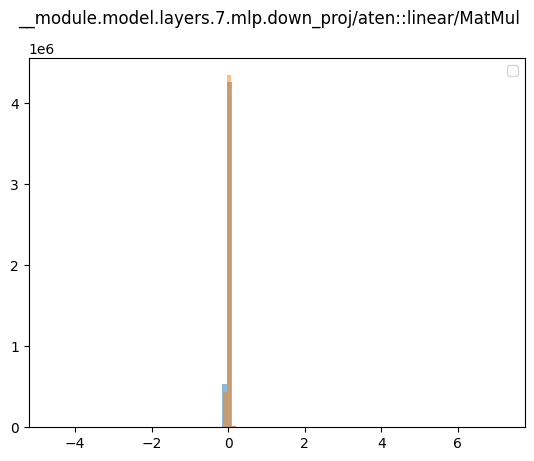

__module.model.layers.8.mlp.down_proj/aten::linear/MatMul
compressed  -1.4324921 2.4721298
fp32  -1.4308599 2.5735736


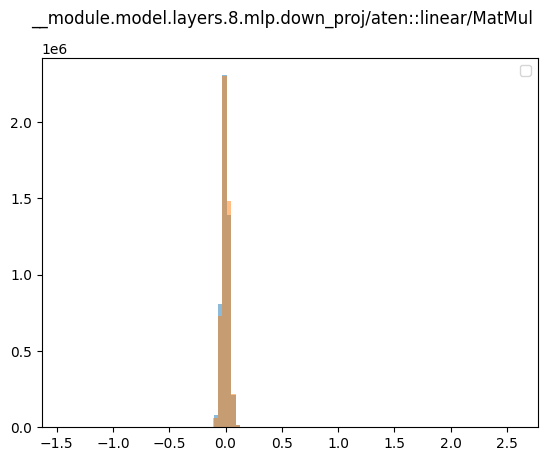

__module.model.layers.9.mlp.down_proj/aten::linear/MatMul
compressed  -0.93337977 1.189686
fp32  -2.945892 1.7331798


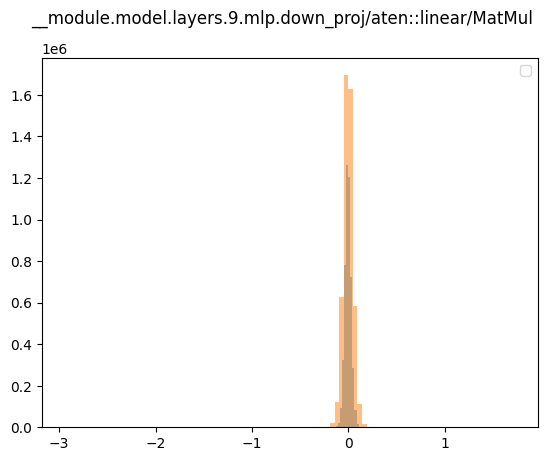

__module.model.layers.10.mlp.down_proj/aten::linear/MatMul
compressed  -0.80153483 1.3237312
fp32  -0.73800415 1.308253


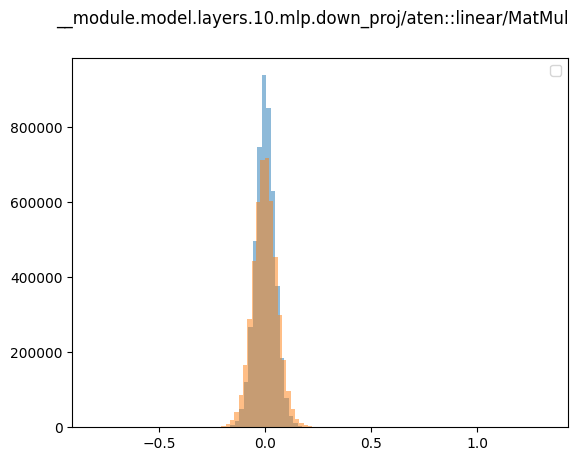

__module.model.layers.11.mlp.down_proj/aten::linear/MatMul
compressed  -0.4574069 1.3136278
fp32  -0.33488524 1.088993


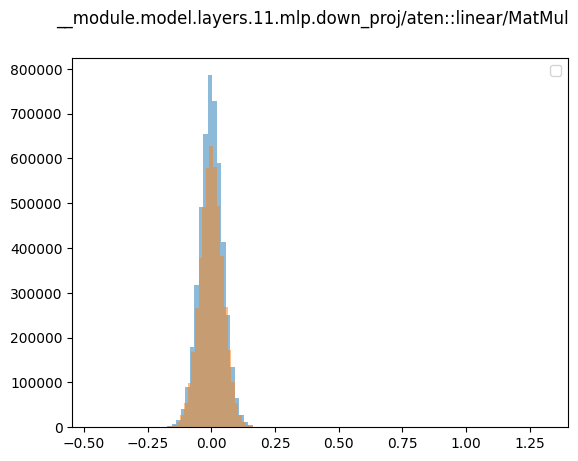

__module.model.layers.12.mlp.down_proj/aten::linear/MatMul
compressed  -0.7549622 1.7377148
fp32  -0.670461 1.0522461


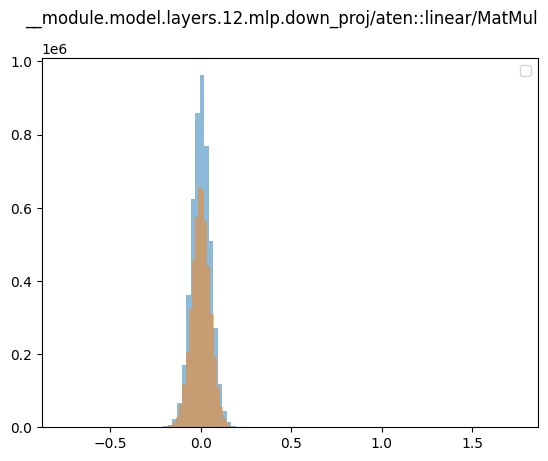

__module.model.layers.13.mlp.down_proj/aten::linear/MatMul
compressed  -0.6304319 1.6323165
fp32  -0.6816063 1.3737453


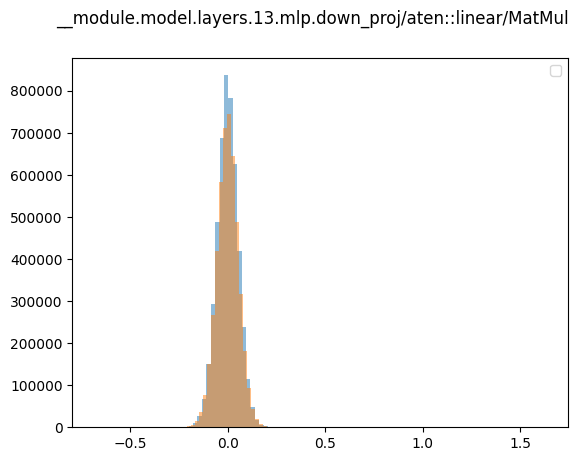

__module.model.layers.14.mlp.down_proj/aten::linear/MatMul
compressed  -1.698017 0.9971163
fp32  -1.2996926 0.9181712


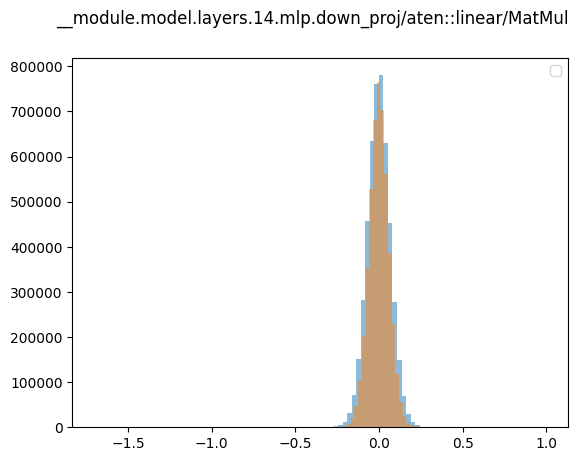

__module.model.layers.15.mlp.down_proj/aten::linear/MatMul
compressed  -1.1598967 2.4010532
fp32  -1.073395 2.0054817


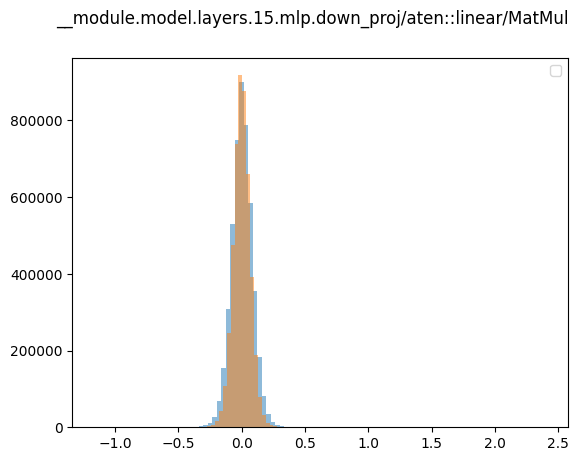

__module.model.layers.16.mlp.down_proj/aten::linear/MatMul
compressed  -1.5036384 3.4052844
fp32  -1.7397318 3.0970306


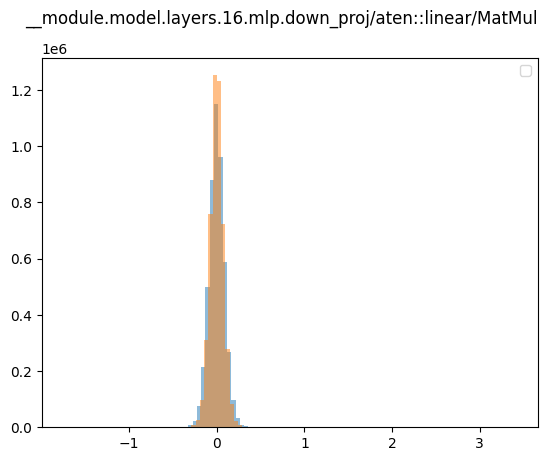

__module.model.layers.17.mlp.down_proj/aten::linear/MatMul
compressed  -1.476418 4.2857366
fp32  -1.415054 3.7547026


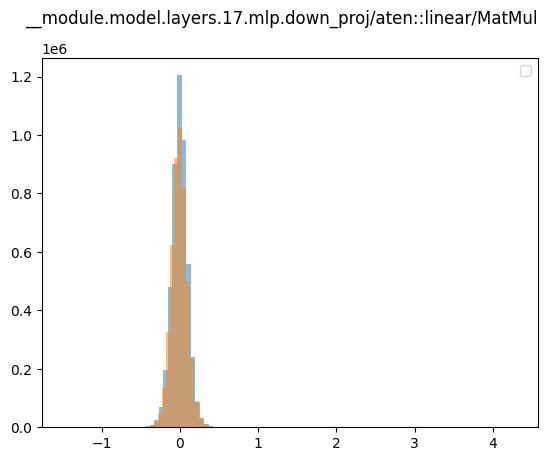

__module.model.layers.18.mlp.down_proj/aten::linear/MatMul
compressed  -1.5736675 3.680425
fp32  -1.2652577 3.3320813


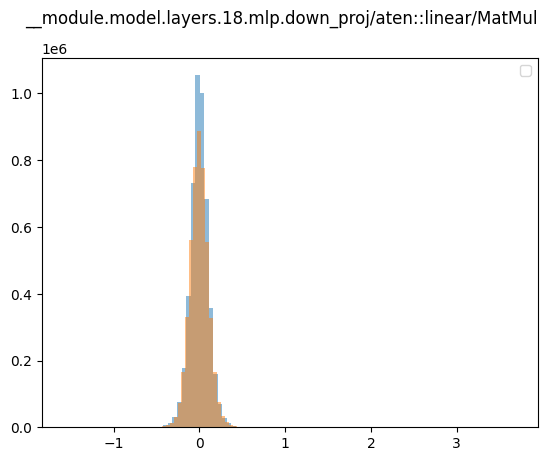

__module.model.layers.19.mlp.down_proj/aten::linear/MatMul
compressed  -78.56027 63.943764
fp32  -77.86475 63.34182


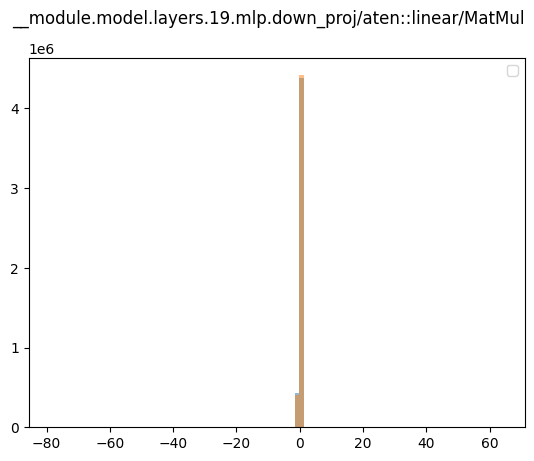

__module.model.layers.20.mlp.down_proj/aten::linear/MatMul
compressed  -5.04958 3.1954803
fp32  -4.791551 3.0860186


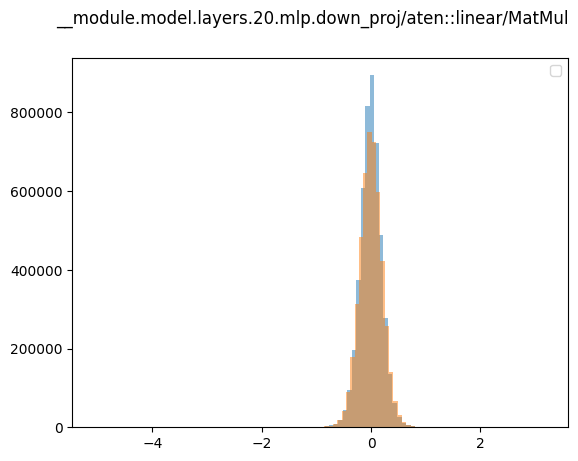

__module.model.layers.21.mlp.down_proj/aten::linear/MatMul
compressed  -120.04524 163.68832
fp32  -118.888275 162.23973


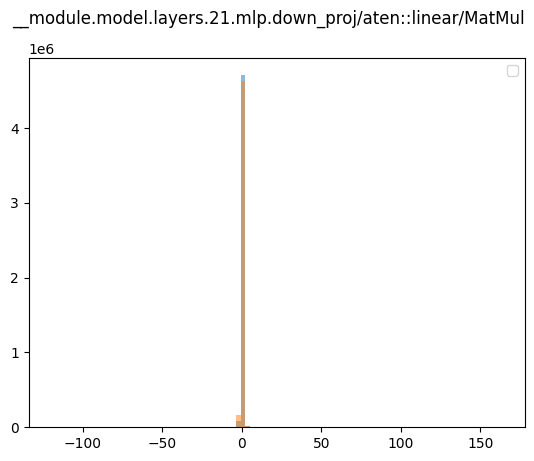

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
reg_names = [
    # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
    # r'__module.model.layers..*\d+.self_attn.v_proj/ov_ext::linear/MatMul',
    # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
    r"__module.model.embed_tokens/aten::embedding/Gather",
    # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
    # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
    # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
    # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
    # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
    # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
]

In [ ]:
for reg_name in reg_names:
    regexp = re.compile(reg_name)
    activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
    activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

    act_types = ["in", "out"]

    for act_type in act_types:
        print("REG Name", reg_name, act_type)

        plot_data = {
            "int": {"mean": [], "std": []},
            "fp": {"mean": [], "std": []},
            "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
        }

        for k in activations_fp:
            int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
            fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
            try:
                int_data = np.concatenate(int_data, axis=1)
                fp_data = np.concatenate(fp_data, axis=1)
            except Exception:
                try:
                    int_data = np.concatenate(int_data, axis=2)
                    fp_data = np.concatenate(fp_data, axis=2)
                except Exception:
                    int_data = np.concatenate(int_data, axis=3)
                    fp_data = np.concatenate(fp_data, axis=3)

            fig, (ax1) = plt.subplots(1)
            fig.suptitle(k)

            ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
            ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
            print(k)
            print("compressed ", int_data.flatten().min(), int_data.flatten().max())
            print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
            plt.legend(loc="best")
            plt.show()

            plot_data["int"]["mean"].append(np.mean(int_data))
            plot_data["fp"]["mean"].append(np.mean(fp_data))
            plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
            plot_data["fp-int"]["relative"].append(
                np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
            )

            plot_data["int"]["std"].append(np.std(int_data))
            plot_data["fp"]["std"].append(np.std(fp_data))
            plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

        x = [i for i in range(len(activations_fp))]

        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
        fig.suptitle("Distributions")

        ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
        ax1.set_title("fp")

        ax2.errorbar(
            x,
            plot_data["int"]["mean"],
            plot_data["int"]["std"],
            linestyle="none",
            marker="^",
            fmt="o",
            ecolor="green",
        )
        ax2.set_title("int")

        ax3.errorbar(
            x,
            plot_data["fp-int"]["mean"],
            plot_data["fp-int"]["std"],
            linestyle="none",
            marker="^",
            fmt="o",
            ecolor="red",
        )
        ax3.set_title("fp-int")

        ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
        ax4.set_title("fp-int relative")

        plt.legend()
        # Save the plot to a file
        output_dir = "activation_plots"
        os.makedirs(output_dir, exist_ok=True)
        safe_name = (
            reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
        )
        plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
        plt.close()

AttributeError: 'str' object has no attribute 'model'

In [ ]:
model_fp

'/home/nlyaly/projects/nncf/tests/post_training/tmp/fp32_models/TinyLlama__TinyLlama_v1.1'

In [ ]:
model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)

NameError: name 'OVModelForCausalLM' is not defined

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 22 target operations matching pattern


/home/nlyaly/env/nncf-py/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Found 22 target operations matching pattern


REG Name __module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul in
__module.model.layers.0.mlp.down_proj/aten::linear/MatMul
compressed  -97.09368 160.91553
fp32  -97.45829 161.26573


<ipython-input-2-64f5f1350421>:349: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


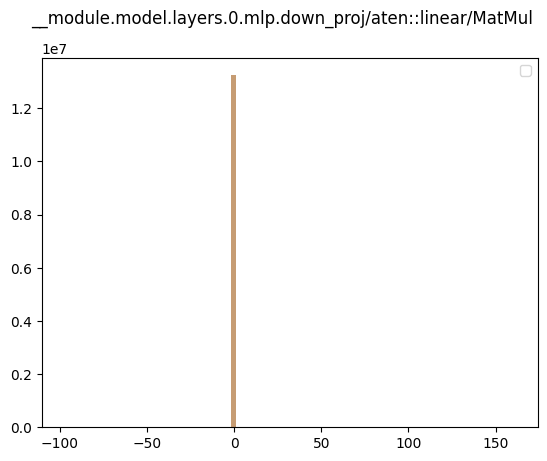

__module.model.layers.1.mlp.down_proj/aten::linear/MatMul
compressed  -10.664949 6.4971247
fp32  -10.60357 6.5329504


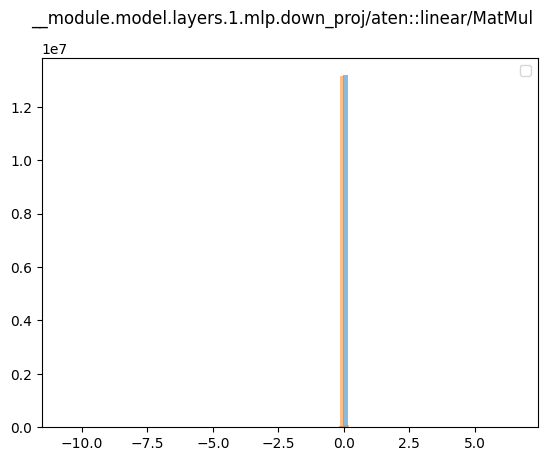

__module.model.layers.2.mlp.down_proj/aten::linear/MatMul
compressed  -0.97614104 1.4614139
fp32  -0.98054796 1.5983243


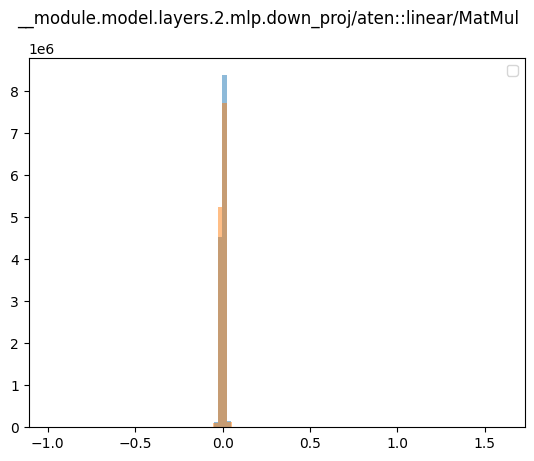

__module.model.layers.3.mlp.down_proj/aten::linear/MatMul
compressed  -1.2524452 1.3031021
fp32  -1.26334 1.3189629


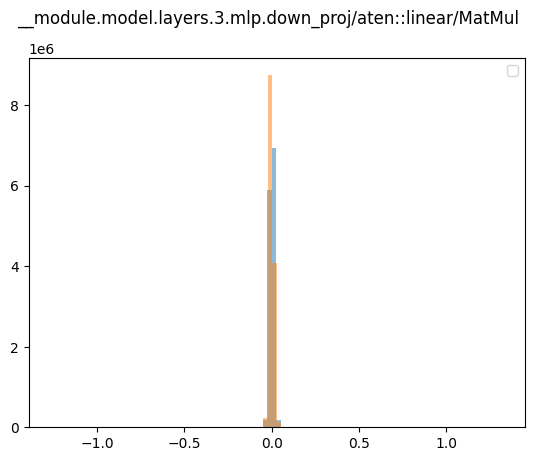

__module.model.layers.4.mlp.down_proj/aten::linear/MatMul
compressed  -0.9780812 1.1453418
fp32  -0.98695093 1.1479772


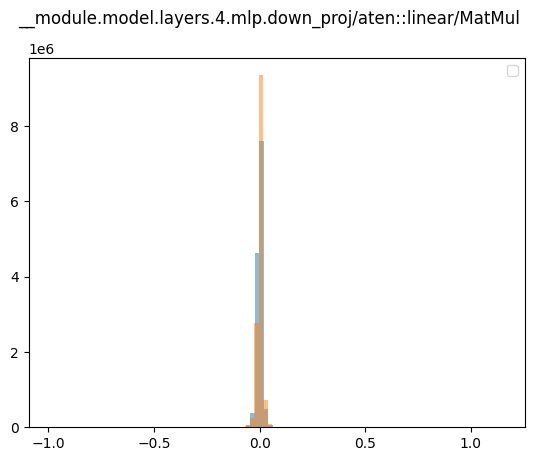

__module.model.layers.5.mlp.down_proj/aten::linear/MatMul
compressed  -1.3967999 1.1984028
fp32  -1.401671 1.1972027


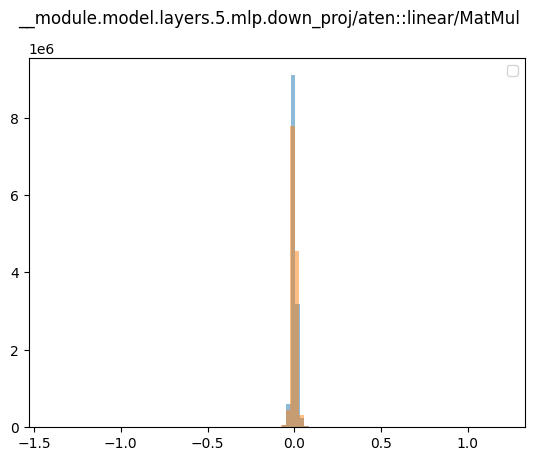

__module.model.layers.6.mlp.down_proj/aten::linear/MatMul
compressed  -1.8136455 1.3324692
fp32  -1.7879211 1.3401906


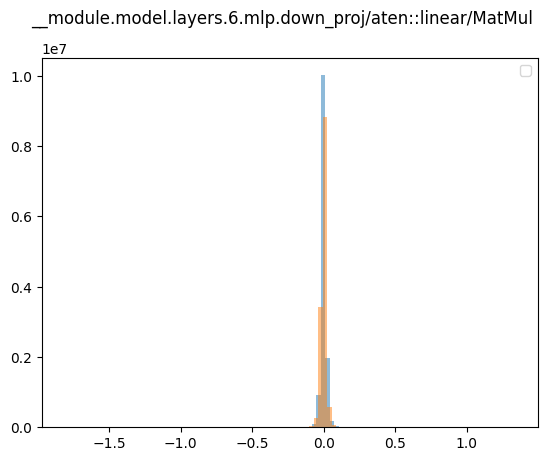

__module.model.layers.7.mlp.down_proj/aten::linear/MatMul
compressed  -1.5152762 6.821211
fp32  -1.5224895 7.041584


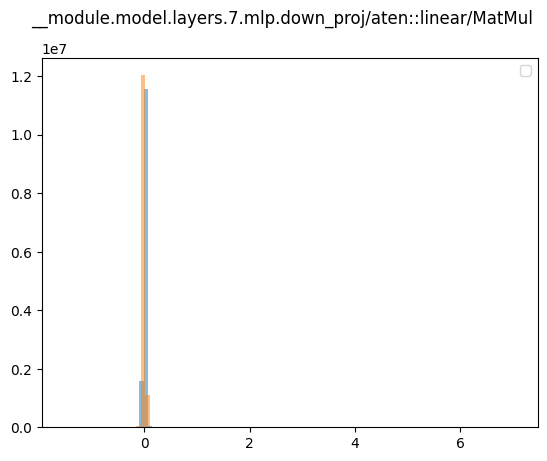

__module.model.layers.8.mlp.down_proj/aten::linear/MatMul
compressed  -1.6777108 2.5076041
fp32  -1.7464732 2.15704


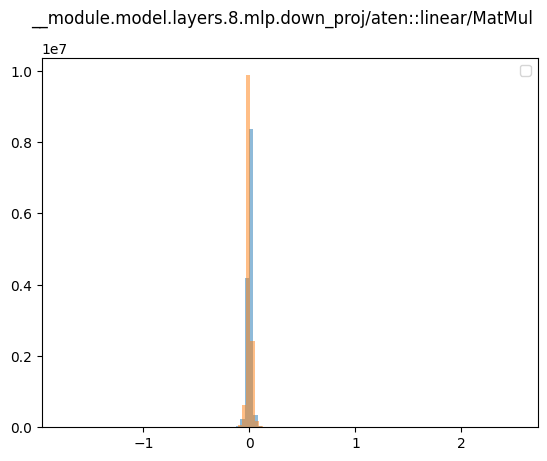

__module.model.layers.9.mlp.down_proj/aten::linear/MatMul
compressed  -3.075603 1.2341598
fp32  -4.1916246 2.183477


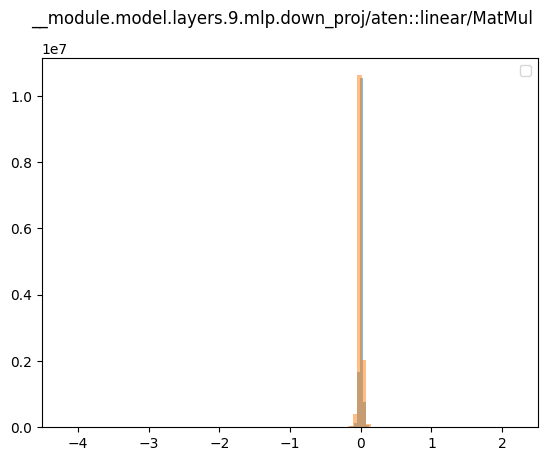

__module.model.layers.10.mlp.down_proj/aten::linear/MatMul
compressed  -2.0421336 5.2184644
fp32  -3.4408185 2.2666535


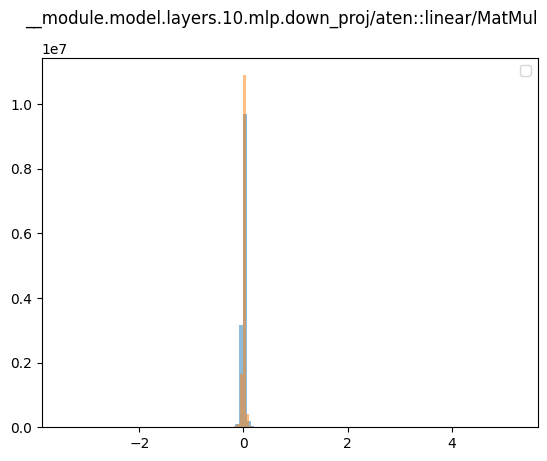

__module.model.layers.11.mlp.down_proj/aten::linear/MatMul
compressed  -2.0823126 2.1082366
fp32  -2.007507 2.3599894


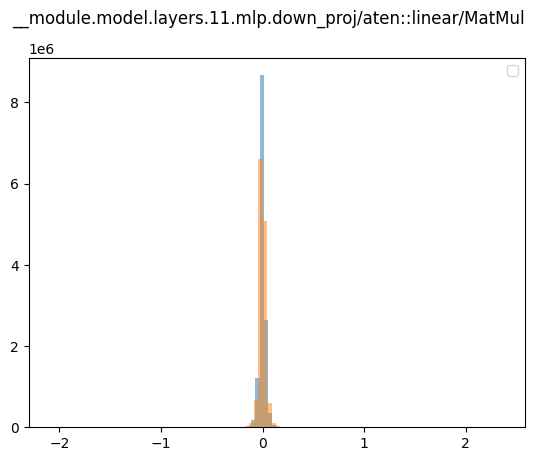

__module.model.layers.12.mlp.down_proj/aten::linear/MatMul
compressed  -4.149282 2.6299396
fp32  -3.9908383 1.6423781


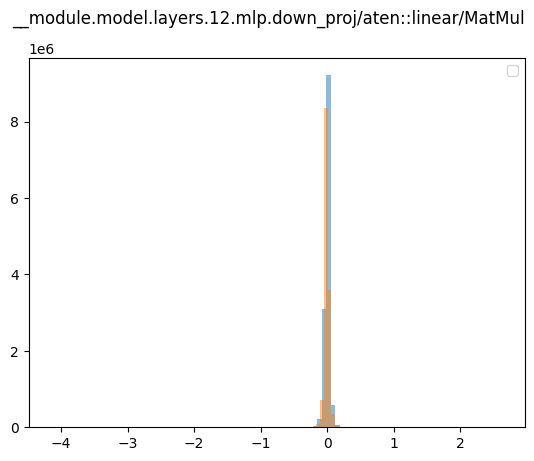

__module.model.layers.13.mlp.down_proj/aten::linear/MatMul
compressed  -2.244259 3.3339245
fp32  -4.1283474 4.3798413


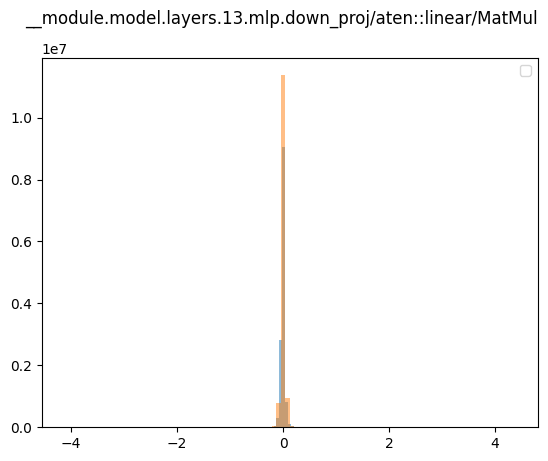

__module.model.layers.14.mlp.down_proj/aten::linear/MatMul
compressed  -4.9597616 4.639678
fp32  -4.71596 3.6561546


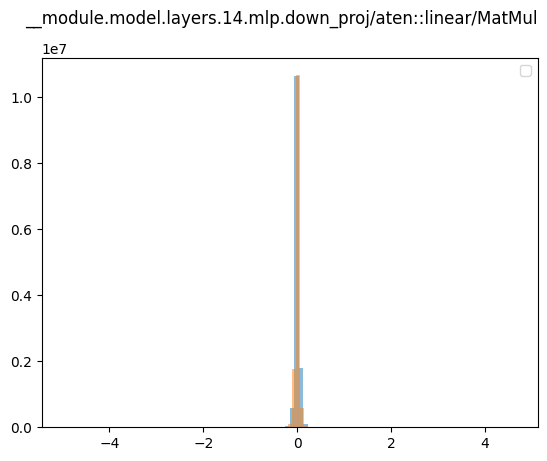

__module.model.layers.15.mlp.down_proj/aten::linear/MatMul
compressed  -7.559886 6.700217
fp32  -6.468946 7.907144


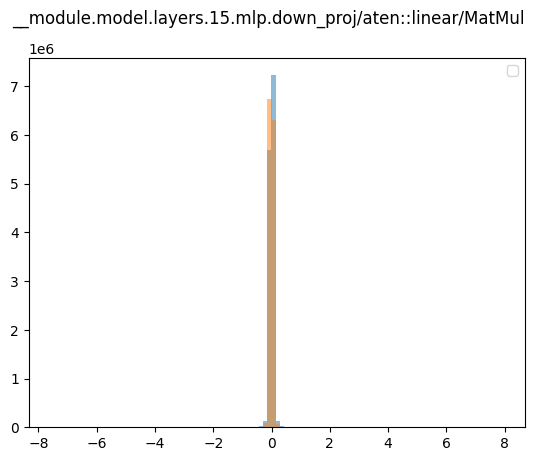

__module.model.layers.16.mlp.down_proj/aten::linear/MatMul
compressed  -8.19541 7.525195
fp32  -6.041764 7.625871


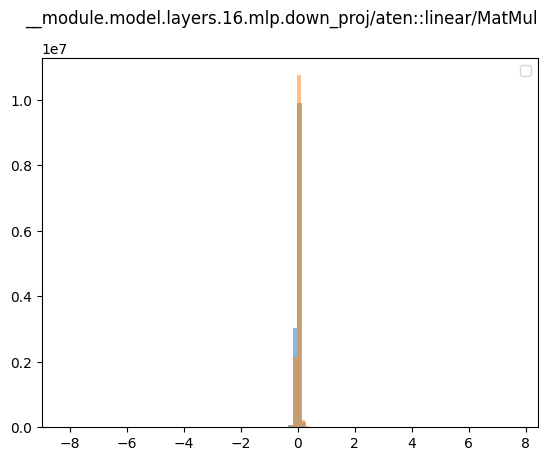

__module.model.layers.17.mlp.down_proj/aten::linear/MatMul
compressed  -7.4131036 6.910467
fp32  -7.2061534 6.977987


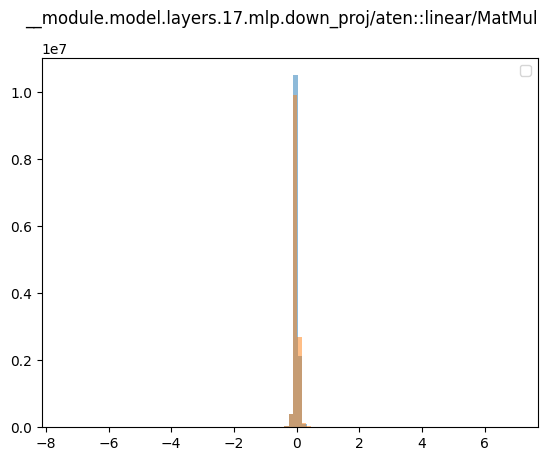

__module.model.layers.18.mlp.down_proj/aten::linear/MatMul
compressed  -8.958774 7.567482
fp32  -5.2913723 7.273148


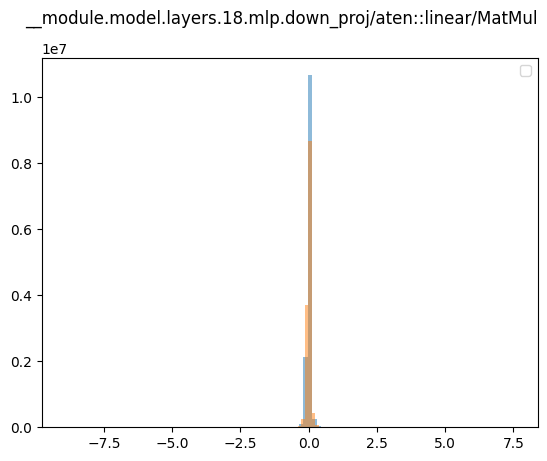

__module.model.layers.19.mlp.down_proj/aten::linear/MatMul
compressed  -9.4002695 125.046906
fp32  -9.695302 123.817604


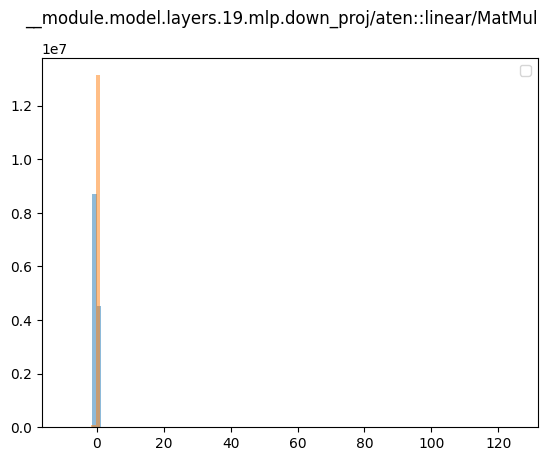

__module.model.layers.20.mlp.down_proj/aten::linear/MatMul
compressed  -11.936077 14.323755
fp32  -11.417531 9.139582


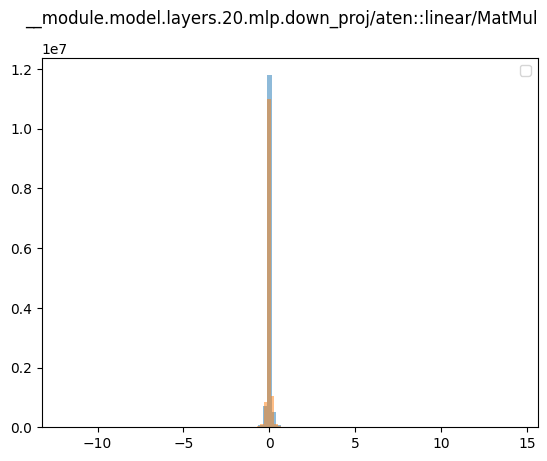

__module.model.layers.21.mlp.down_proj/aten::linear/MatMul
compressed  -106.36025 50.86884
fp32  -105.20638 37.196194


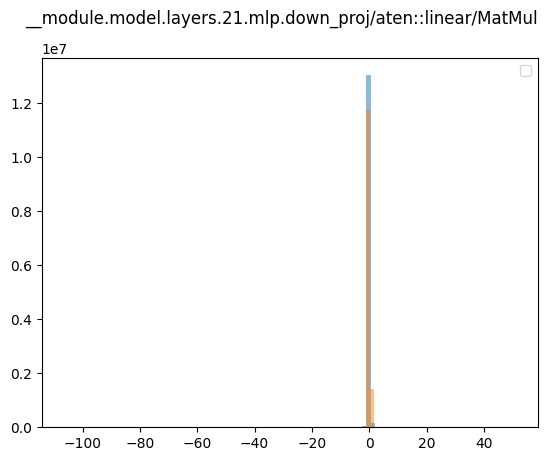

<ipython-input-2-64f5f1350421>:371: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-2-64f5f1350421>:382: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul out
__module.model.layers.0.mlp.down_proj/aten::linear/MatMul
compressed  -166.7331 96.776215
fp32  -166.52237 97.151146


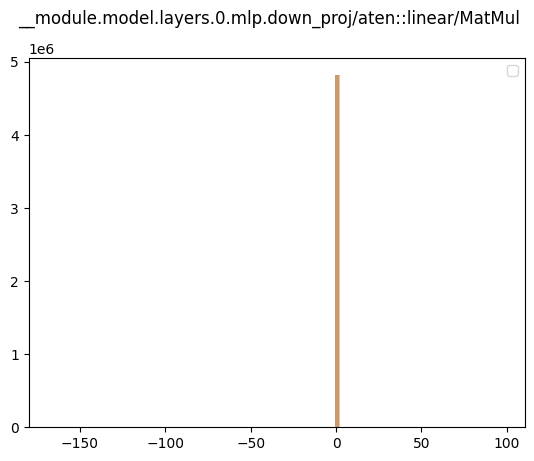

__module.model.layers.1.mlp.down_proj/aten::linear/MatMul
compressed  -15.269519 22.597515
fp32  -15.242815 22.547516


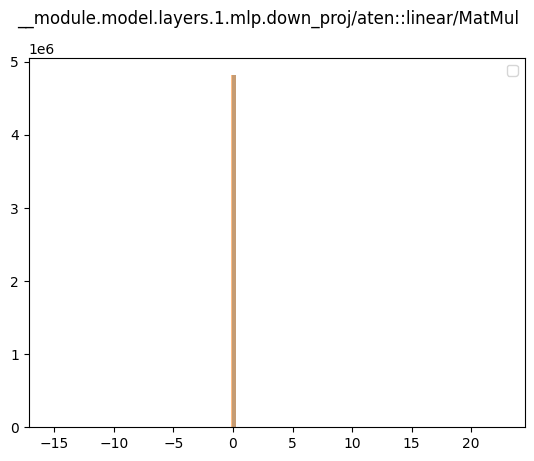

__module.model.layers.2.mlp.down_proj/aten::linear/MatMul
compressed  -0.96045864 0.6646261
fp32  -1.0562836 0.65111256


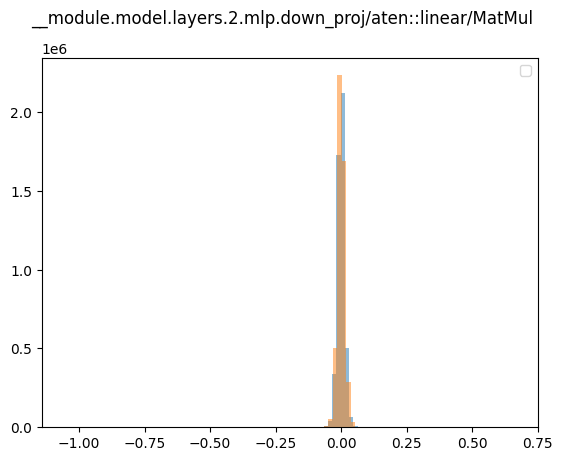

__module.model.layers.3.mlp.down_proj/aten::linear/MatMul
compressed  -0.17253684 0.53509873
fp32  -0.17015783 0.5276194


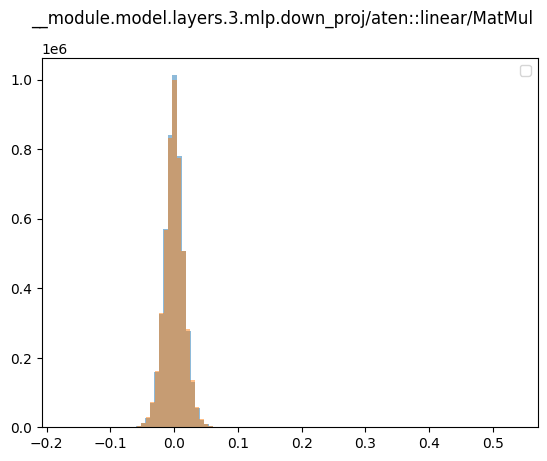

__module.model.layers.4.mlp.down_proj/aten::linear/MatMul
compressed  -0.23792475 0.6152095
fp32  -0.24533877 0.61524594


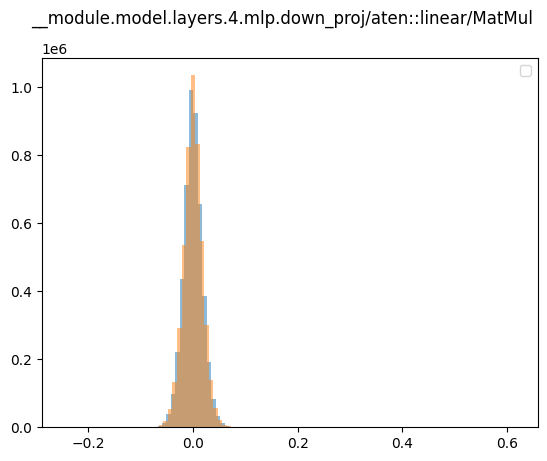

__module.model.layers.5.mlp.down_proj/aten::linear/MatMul
compressed  -0.2572133 0.8018544
fp32  -0.25403988 0.80505747


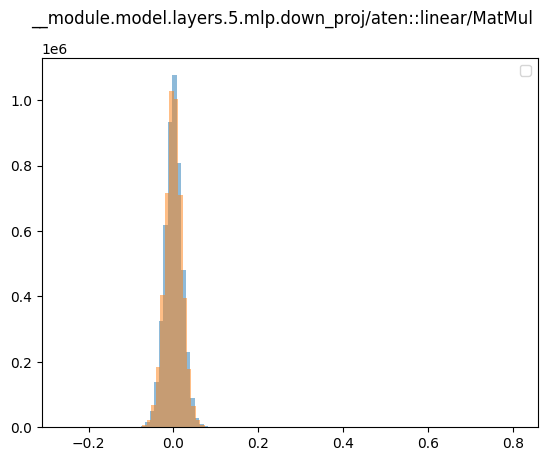

__module.model.layers.6.mlp.down_proj/aten::linear/MatMul
compressed  -0.9946505 2.2660396
fp32  -0.9972433 2.2734718


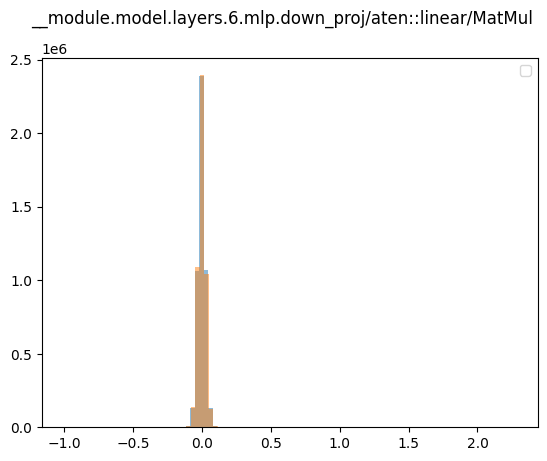

__module.model.layers.7.mlp.down_proj/aten::linear/MatMul
compressed  -4.626007 7.1548686
fp32  -4.4858446 6.928575


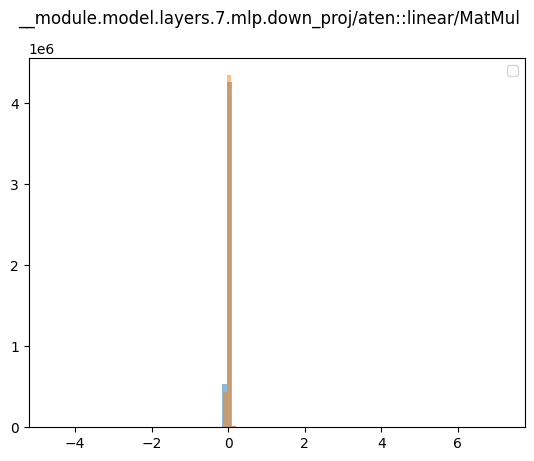

__module.model.layers.8.mlp.down_proj/aten::linear/MatMul
compressed  -1.4324921 2.4721298
fp32  -1.4308599 2.5735736


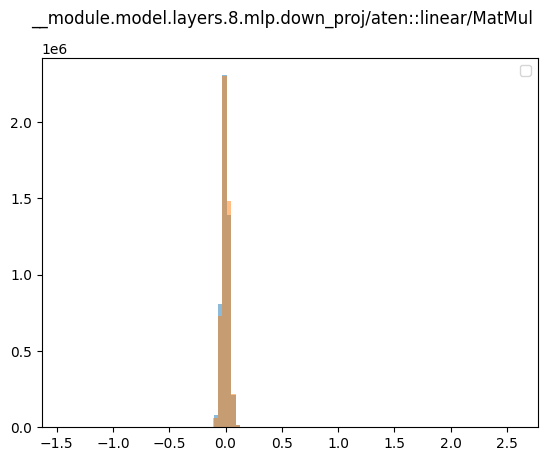

__module.model.layers.9.mlp.down_proj/aten::linear/MatMul
compressed  -0.93337977 1.189686
fp32  -2.945892 1.7331798


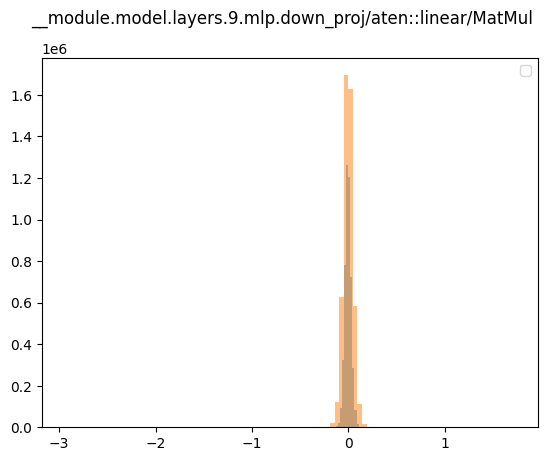

__module.model.layers.10.mlp.down_proj/aten::linear/MatMul
compressed  -0.80153483 1.3237312
fp32  -0.73800415 1.308253


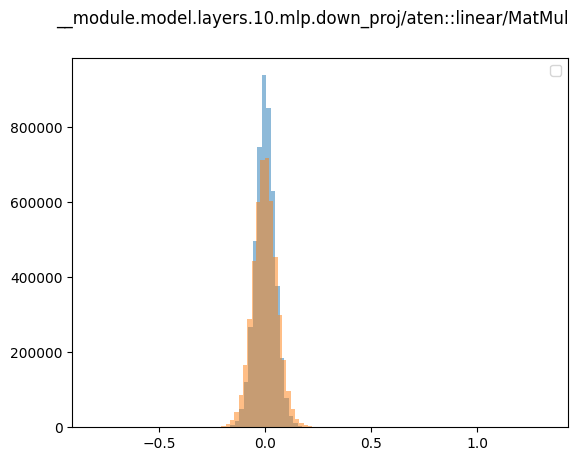

__module.model.layers.11.mlp.down_proj/aten::linear/MatMul
compressed  -0.4574069 1.3136278
fp32  -0.33488524 1.088993


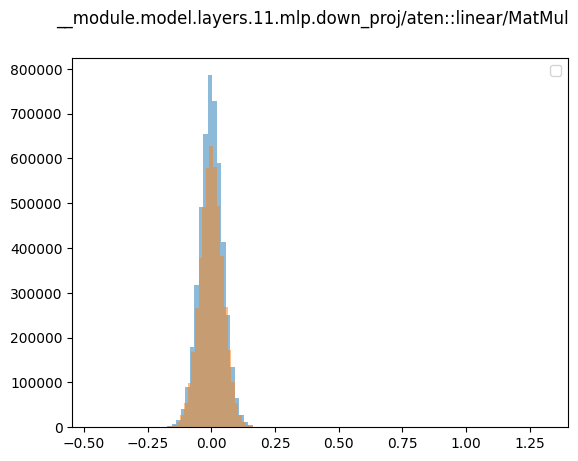

__module.model.layers.12.mlp.down_proj/aten::linear/MatMul
compressed  -0.7549622 1.7377148
fp32  -0.670461 1.0522461


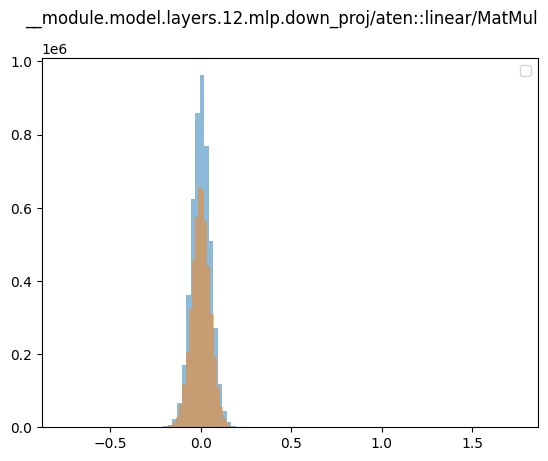

__module.model.layers.13.mlp.down_proj/aten::linear/MatMul
compressed  -0.6304319 1.6323165
fp32  -0.6816063 1.3737453


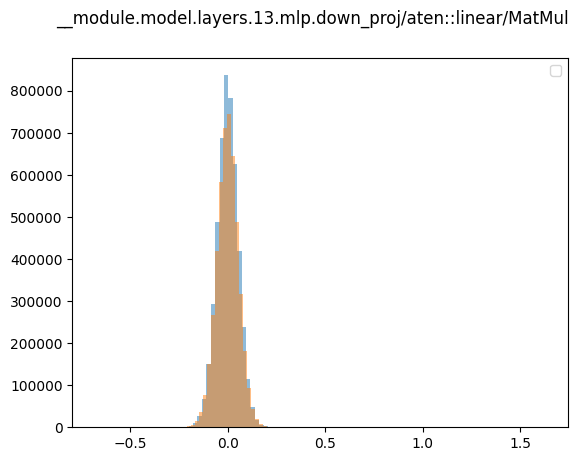

__module.model.layers.14.mlp.down_proj/aten::linear/MatMul
compressed  -1.698017 0.9971163
fp32  -1.2996926 0.9181712


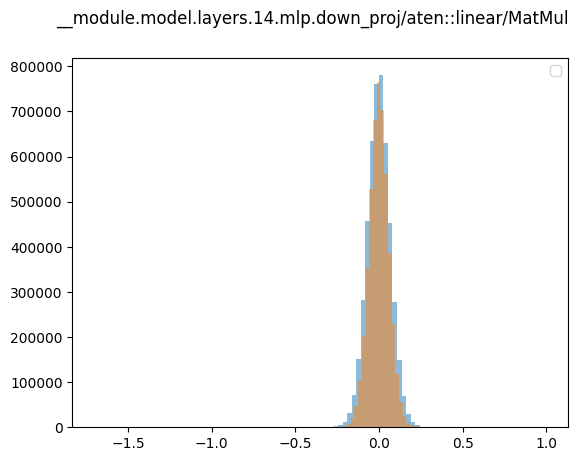

__module.model.layers.15.mlp.down_proj/aten::linear/MatMul
compressed  -1.1598967 2.4010532
fp32  -1.073395 2.0054817


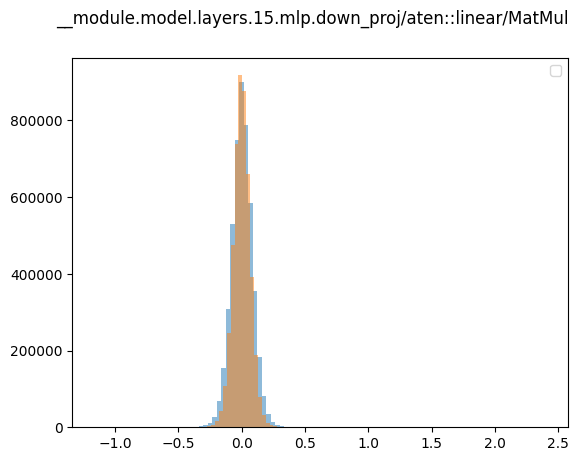

__module.model.layers.16.mlp.down_proj/aten::linear/MatMul
compressed  -1.5036384 3.4052844
fp32  -1.7397318 3.0970306


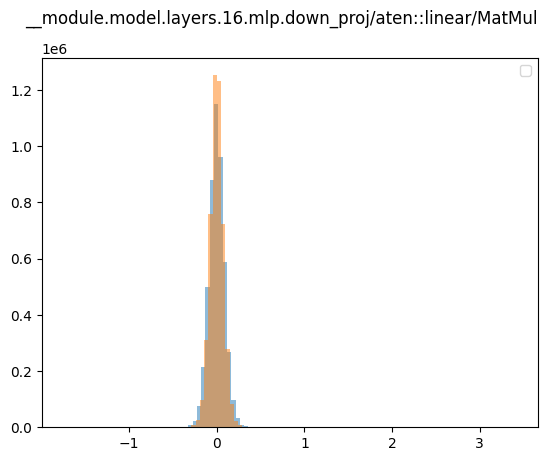

__module.model.layers.17.mlp.down_proj/aten::linear/MatMul
compressed  -1.476418 4.2857366
fp32  -1.415054 3.7547026


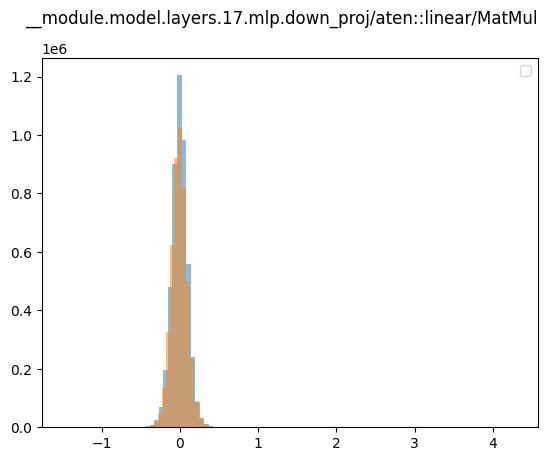

__module.model.layers.18.mlp.down_proj/aten::linear/MatMul
compressed  -1.5736675 3.680425
fp32  -1.2652577 3.3320813


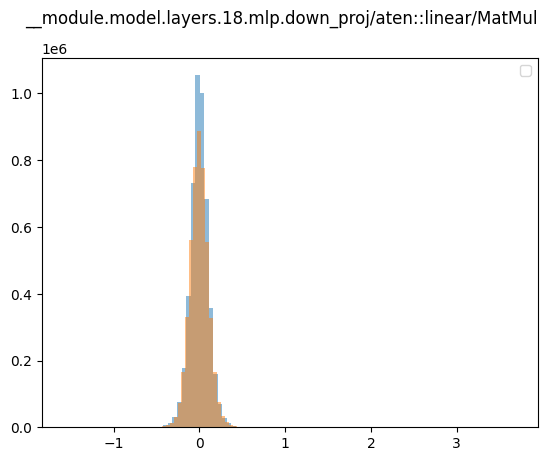

__module.model.layers.19.mlp.down_proj/aten::linear/MatMul
compressed  -78.56027 63.943764
fp32  -77.86475 63.34182


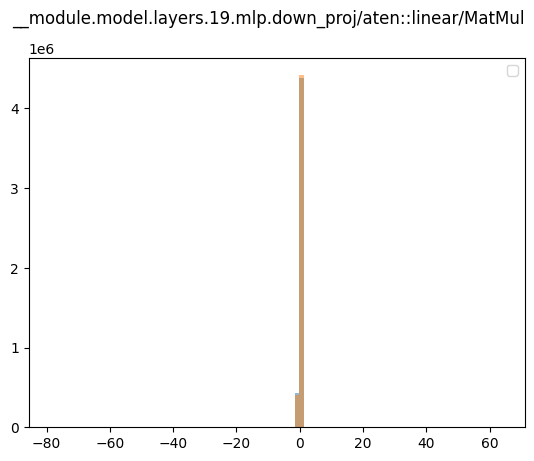

__module.model.layers.20.mlp.down_proj/aten::linear/MatMul
compressed  -5.04958 3.1954803
fp32  -4.791551 3.0860186


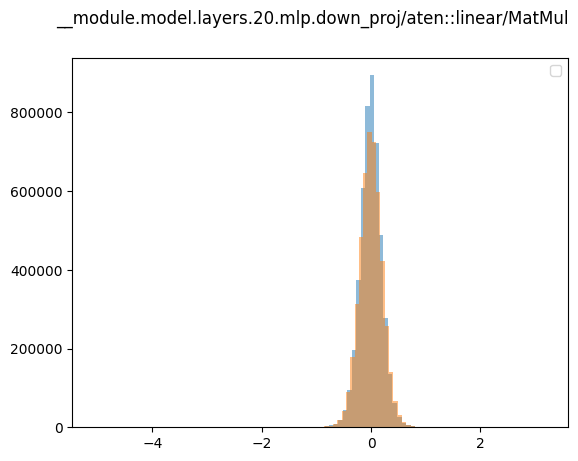

__module.model.layers.21.mlp.down_proj/aten::linear/MatMul
compressed  -120.04524 163.68832
fp32  -118.888275 162.23973


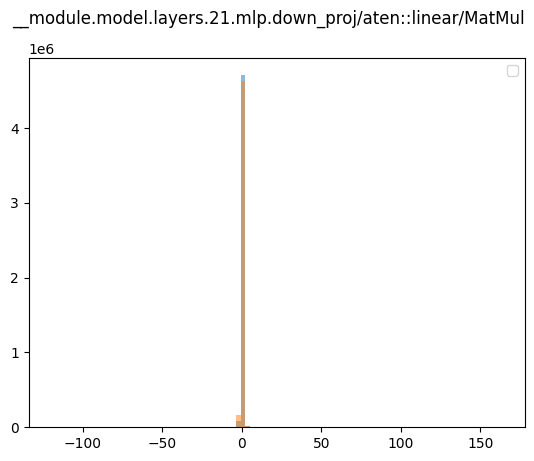

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r'__module.model.layers..*\d+.self_attn.v_proj/ov_ext::linear/MatMul',
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        r"__module.model.embed_tokens/aten::embedding/Gather",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 1 target operations matching pattern


Found 1 target operations matching pattern


REG Name __module.model.embed_tokens/aten::embedding/Gather in
__module.model.embed_tokens/aten::embedding/Gather
compressed  -0.14358759 0.10308266
fp32  -0.14337036 0.10325463


<ipython-input-11-1912c402a924>:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


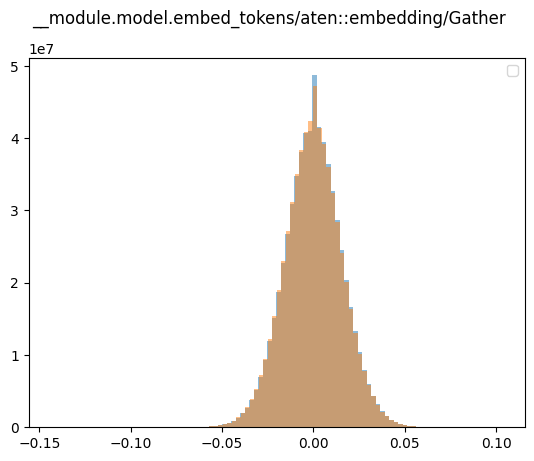

<ipython-input-11-1912c402a924>:105: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-11-1912c402a924>:116: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.model.embed_tokens/aten::embedding/Gather out
__module.model.embed_tokens/aten::embedding/Gather
compressed  -0.14358759 0.09678459
fp32  -0.14337036 0.096832015


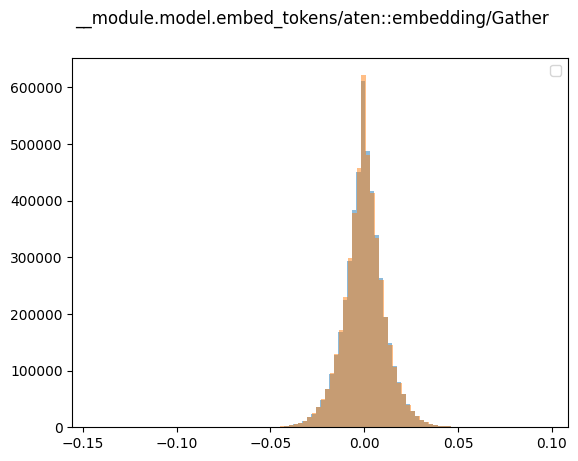

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r'__module.model.layers..*\d+.self_attn.v_proj/ov_ext::linear/MatMul',
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        # r"__module.model.embed_tokens/aten::embedding/Gather",
        r"__module.lm_head/aten::linear/MatMul",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 1 target operations matching pattern


Found 1 target operations matching pattern


REG Name __module.lm_head/aten::linear/MatMul in
__module.lm_head/aten::linear/MatMul
compressed  -64.116264 34.78303
fp32  -45.655186 29.958374


<ipython-input-13-8a95c89c701d>:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


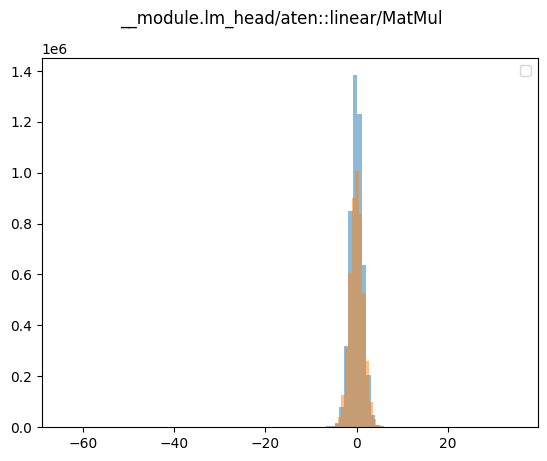

<ipython-input-13-8a95c89c701d>:106: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-13-8a95c89c701d>:117: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.lm_head/aten::linear/MatMul out
__module.lm_head/aten::linear/MatMul
compressed  -31.294125 29.051762
fp32  -32.855797 23.98816


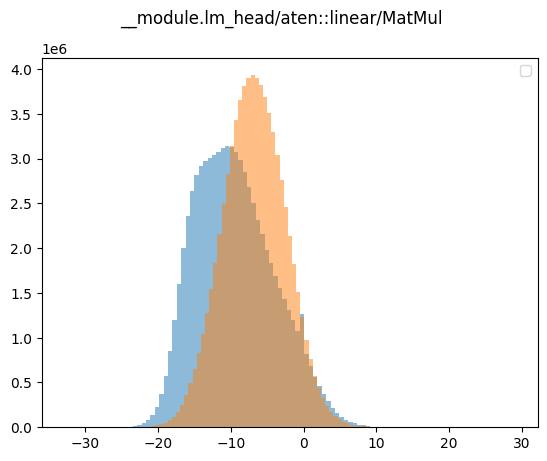

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
model_int_ign_emb = "/home/nlyaly/projects/nncf/tests/post_training/tmp/tinyllama_int8_data_free_ign_emb/TORCH"

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 1 target operations matching pattern


Found 1 target operations matching pattern


REG Name __module.lm_head/aten::linear/MatMul in
__module.lm_head/aten::linear/MatMul
compressed  -45.706356 29.872177
fp32  -45.655186 29.958374


<ipython-input-13-8a95c89c701d>:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


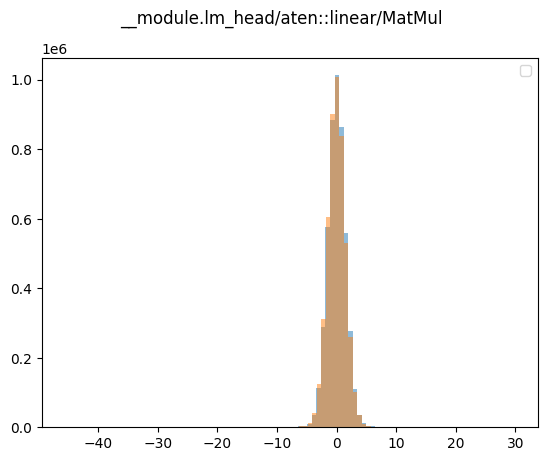

<ipython-input-13-8a95c89c701d>:106: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-13-8a95c89c701d>:117: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.lm_head/aten::linear/MatMul out
__module.lm_head/aten::linear/MatMul
compressed  -32.795692 23.648266
fp32  -32.855797 23.98816


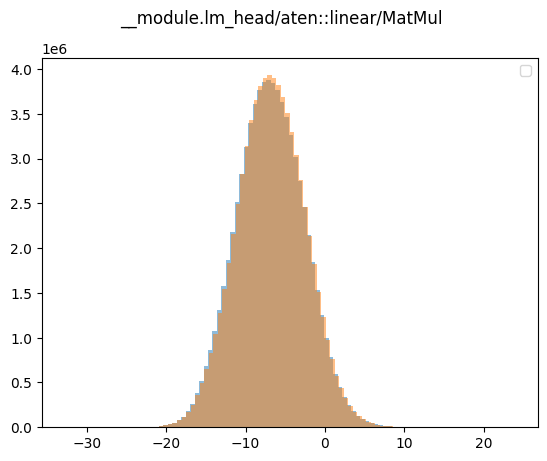

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int_ign_emb,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r'__module.model.layers..*\d+.self_attn.v_proj/ov_ext::linear/MatMul',
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        r"__module.model.embed_tokens/aten::embedding/Gather",
        # r"__module.lm_head/aten::linear/MatMul",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 1 target operations matching pattern


Found 1 target operations matching pattern


REG Name __module.model.embed_tokens/aten::embedding/Gather in
__module.model.embed_tokens/aten::embedding/Gather
compressed  -0.14337036 0.10325463
fp32  -0.14337036 0.10325463


<ipython-input-17-a320de28ae11>:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


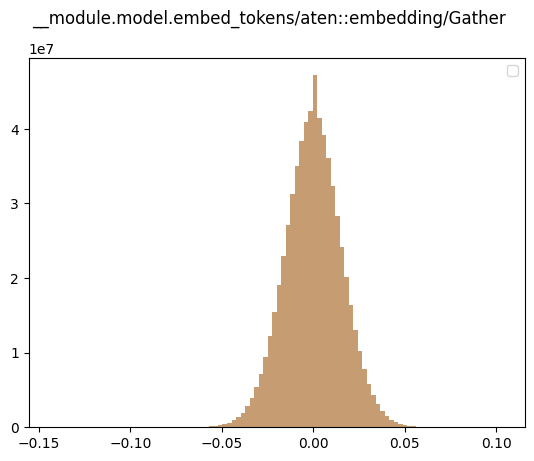

<ipython-input-17-a320de28ae11>:106: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-17-a320de28ae11>:117: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.model.embed_tokens/aten::embedding/Gather out
__module.model.embed_tokens/aten::embedding/Gather
compressed  -0.14337036 0.096832015
fp32  -0.14337036 0.096832015


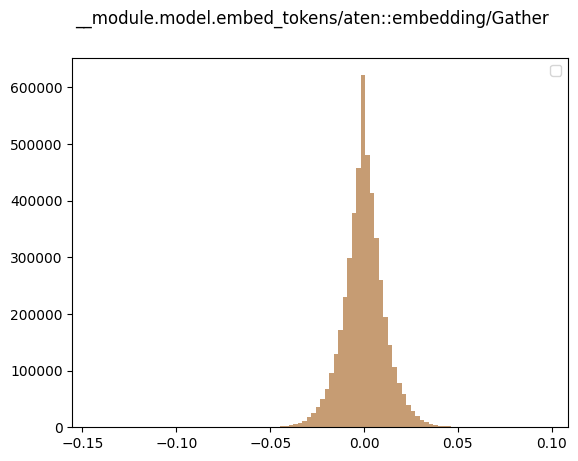

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int_ign_emb,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Could not infer whether the model was already converted or not to the OpenVINO IR, keeping `export=False`.
Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/home/nlyaly/projects/nncf/tests/post_training/tmp/tinyllama_int8_data_free/TORCH'. Use `repo_type` argument if needed.


HFValidationError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/home/nlyaly/projects/nncf/tests/post_training/tmp/tinyllama_int8_data_free/TORCH'. Use `repo_type` argument if needed.

In [ ]:
model_int = "/home/nlyaly/projects/nncf/tests/post_training/tmp/tinyllama_int8_data_free_full_int8/TORCH"

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 1 target operations matching pattern


Found 1 target operations matching pattern


REG Name __module.model.embed_tokens/aten::embedding/Gather in
__module.model.embed_tokens/aten::embedding/Gather
compressed  -0.14358759 0.10308266
fp32  -0.14337036 0.10325463


<ipython-input-17-a320de28ae11>:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


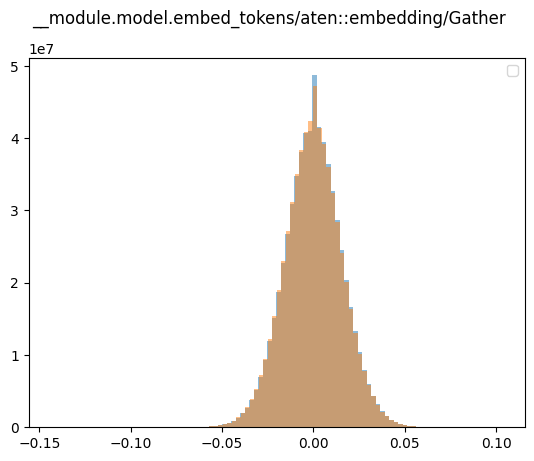

<ipython-input-17-a320de28ae11>:106: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-17-a320de28ae11>:117: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.model.embed_tokens/aten::embedding/Gather out
__module.model.embed_tokens/aten::embedding/Gather
compressed  -0.14358759 0.09678459
fp32  -0.14337036 0.096832015


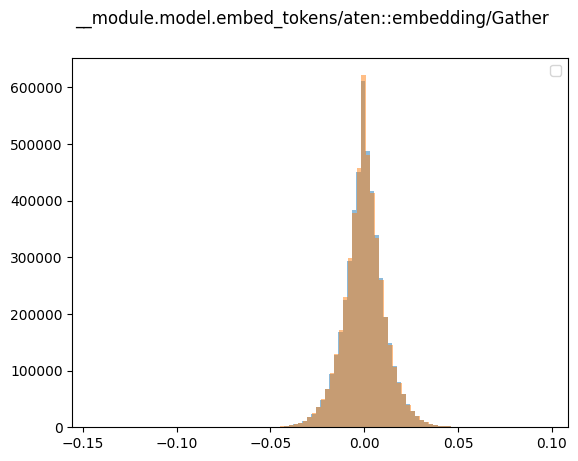

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        r"__module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul",
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        # r"__module.model.embed_tokens/aten::embedding/Gather",
        # r"__module.lm_head/aten::linear/MatMul",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


No operations found matching pattern: __module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul
No operations found matching pattern: __module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul
REG Name __module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul in
REG Name __module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul out


<ipython-input-22-cf1d81540c3f>:106: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-22-cf1d81540c3f>:117: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


In [ ]:
def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r"__module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul",
        r"__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul",
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        # r"__module.model.embed_tokens/aten::embedding/Gather",
        # r"__module.lm_head/aten::linear/MatMul",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 1 target operations matching pattern


Found 1 target operations matching pattern


REG Name __module.model.layers.0.self_attn.q_proj/aten::linear/MatMul in
__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul
compressed  -5.62955 6.437337
fp32  -5.6420746 6.4607506


<ipython-input-24-5a9eeda6766c>:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


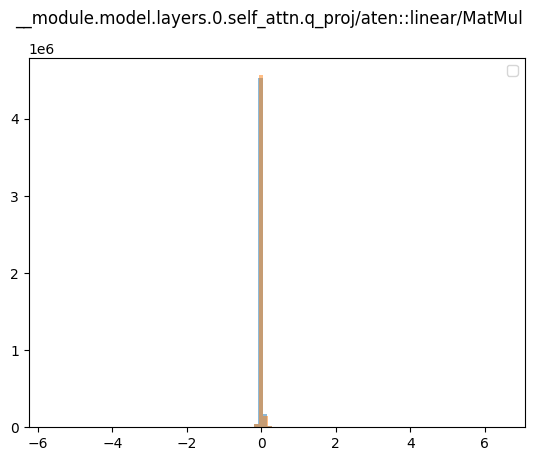

<ipython-input-24-5a9eeda6766c>:107: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-24-5a9eeda6766c>:118: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.model.layers.0.self_attn.q_proj/aten::linear/MatMul out
__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul
compressed  -10.111078 10.616546
fp32  -10.117149 10.604626


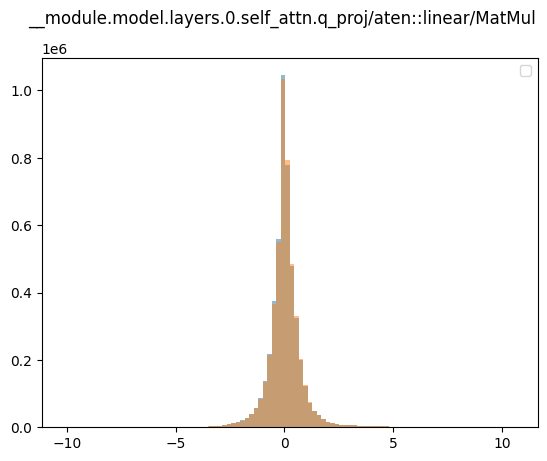

In [ ]:
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r"__module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul",
        r"__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul",
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        r"__module.model.embed_tokens/aten::embedding/Gather",
        r"__module.lm_head/aten::linear/MatMul",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 1 target operations matching pattern


Found 1 target operations matching pattern


REG Name __module.model.layers.0.self_attn.q_proj/aten::linear/MatMul in
__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul
compressed  -5.62955 6.437337
fp32  -5.6420746 6.4607506


<ipython-input-26-00846e8c74c1>:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


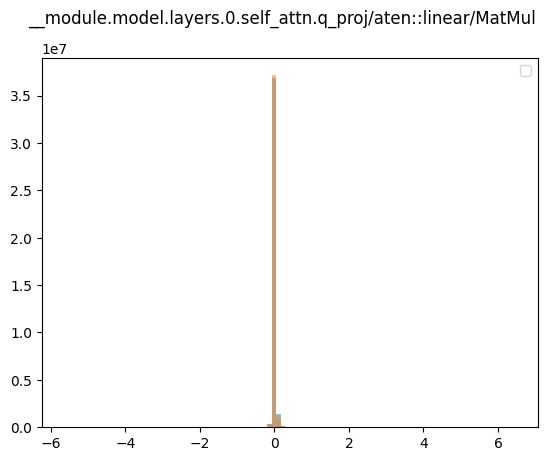

<ipython-input-26-00846e8c74c1>:107: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-26-00846e8c74c1>:118: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.model.layers.0.self_attn.q_proj/aten::linear/MatMul out
__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul
compressed  -10.111078 10.870653
fp32  -10.117149 10.8530245


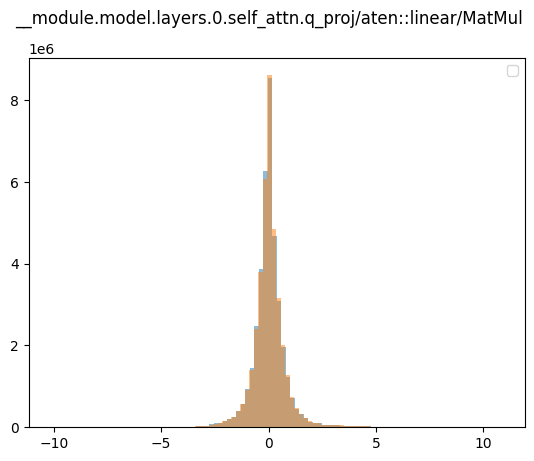

Found 1 target operations matching pattern


Found 1 target operations matching pattern


REG Name __module.model.embed_tokens/aten::embedding/Gather in


In [ ]:
n_samples = 128
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r"__module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul",
        # r"__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul",
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        r"__module.model.embed_tokens/aten::embedding/Gather",
        # r"__module.lm_head/aten::linear/MatMul",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

In [ ]:
n_samples = 128
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

NameError: name 'model_fp' is not defined

In [ ]:
def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r"__module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul",
        # r"__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul",
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        r"__module.model.embed_tokens/aten::embedding/Gather",
        # r"__module.lm_head/aten::linear/MatMul",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

: 

Restarted nncf-py (Python 3.10.16)

In [ ]:
#!/usr/bin/env python3
# Copyright (c) 2025 Intel Corporation
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#      http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

"""
Example script demonstrating how to use the draw_activations_2 function
for comparing floating point and quantized model activations with histograms.
"""

import os
import re
from typing import Any, Optional

import numpy as np
import openvino as ov
from datasets import load_dataset
from transformers import AutoTokenizer

from nncf.common.graph.transformations.commands import TargetType
from nncf.common.tensor_statistics.statistic_point import StatisticPoint
from nncf.common.tensor_statistics.statistic_point import StatisticPointsContainer
from nncf.openvino.graph.nncf_graph_builder import GraphConverter
from nncf.openvino.graph.transformations.commands import OVTargetPoint
from nncf.openvino.statistics.aggregator import OVStatisticsAggregator
from nncf.openvino.statistics.collectors import get_raw_stat_collector


def gen_pkv(n_vals, sz, f_size=12):  # opt-125m
    res = {}
    # "?,12,?,64"
    for i in range(n_vals):
        res[f"past_key_values.{i}.value"] = np.zeros((1, f_size, 0, sz))
        res[f"past_key_values.{i}.key"] = np.zeros((1, f_size, 0, sz))

    return res


def gen_pkv_(n_vals, sz):  # redpajama
    res = {}
    # "?,32,?,128"
    for i in range(n_vals):
        res[f"past_key_values.{i}.value"] = np.zeros((1, 32, 0, sz))
        res[f"past_key_values.{i}.key"] = np.zeros((1, 32, 0, sz))

    return res


def transform_fn(data, model, tokenizer):
    tokenized_text = tokenizer(data["text"], return_tensors="np")
    input_ids = tokenized_text["input_ids"]
    attention_mask = tokenized_text["attention_mask"]

    batch_size = input_ids.shape[0]
    input_shapes = {}
    for val in model.model.inputs:
        name = val.any_name
        shape = list(val.partial_shape.get_min_shape())
        shape[0] = batch_size
        input_shapes[name] = shape

    inputs = {}
    inputs["input_ids"] = input_ids
    inputs["attention_mask"] = tokenized_text["attention_mask"]
    position_ids = np.cumsum(attention_mask, axis=1) - 1
    position_ids[attention_mask == 0] = 1

    # The magic forms KV cache as model inputs
    batch_size = input_ids.shape[0]
    for input_name in model.key_value_input_names:
        model_inputs = model.model.input(input_name)
        shape = model_inputs.get_partial_shape()
        shape[0] = batch_size
        if shape[2].is_dynamic:
            shape[2] = 0
        else:
            shape[1] = 0
        inputs[input_name] = ov.Tensor(model_inputs.get_element_type(), shape.get_shape())

    if "beam_idx" in input_shapes:
        inputs["beam_idx"] = np.arange(batch_size, dtype=int)

    inputs["position_ids"] = position_ids
    return inputs


def get_noop_statistic_collector(
    num_samples: int, channel_axis: int, window_size: Optional[int] = None, inplace: bool = True
):
    """
    Raw statistic collector builder.

    :param num_samples: Maximum number of samples to collect.
    :param channel_axis: Channel axis to use during reduction phase.
    :param window_size: Number of samples from the end of the list of collected samples to aggregate.
        Aggregates all available collected statistics in case parameter is None.
    :param inplace: Whether the mean reducer should be calculated inplace or out of place.
    :return: Mean statistic collector.
    """
    from nncf.experimental.common.tensor_statistics.collectors import NoopAggregator
    from nncf.experimental.common.tensor_statistics.collectors import RawReducer
    from nncf.experimental.common.tensor_statistics.collectors import TensorCollector

    reducer = RawReducer()
    aggregate_mean = NoopAggregator(num_samples)

    collector = TensorCollector()
    collector.register_statistic_branch("MEAN_STAT", reducer, aggregate_mean)
    return collector


def get_statistic_points(model, graph, nodes, subset_size) -> StatisticPointsContainer:
    statistic_container = StatisticPointsContainer()
    OUTPUT_PORT_OF_NODE = 0
    INPUT_PORT_OF_NODE = 0

    # Collection of statistics after/before layers.
    for node in nodes:
        node_name = node.node_name
        channel_axis = node.metatype.output_channel_axis
        if channel_axis is None:
            channel_axis = -1

        # For layers with weights, there is only one output port - 0.
        statistic_point_out = OVTargetPoint(TargetType.POST_LAYER_OPERATION, node_name, port_id=OUTPUT_PORT_OF_NODE)
        stat_collector_out = get_raw_stat_collector(num_samples=subset_size)
        statistic_container.add_statistic_point(
            StatisticPoint(target_point=statistic_point_out, tensor_collector=stat_collector_out, algorithm="collect")
        )

        # For layers with weights, there is only one output port - 0.
        statistic_point_in = OVTargetPoint(TargetType.PRE_LAYER_OPERATION, node_name, port_id=INPUT_PORT_OF_NODE)
        stat_collector_in = get_raw_stat_collector(num_samples=subset_size)
        statistic_container.add_statistic_point(
            StatisticPoint(target_point=statistic_point_in, tensor_collector=stat_collector_in, algorithm="collect")
        )

    return statistic_container


def get_input_statistic_points(model, graph, nodes, subset_size) -> StatisticPointsContainer:
    statistic_container = StatisticPointsContainer()
    INPUT_PORT_OF_NODE = 1
    OUTPUT_PORT_OF_NODE = 0

    # Collection of statistics after/before layers.
    for node in nodes:
        node_name = node.node_name
        channel_axis = node.metatype.output_channel_axis
        if channel_axis is None:
            channel_axis = -1

        # For layers with weights, there is only one output port - 0.
        statistic_point_in = OVTargetPoint(TargetType.PRE_LAYER_OPERATION, node_name, port_id=INPUT_PORT_OF_NODE)
        stat_collector_in = get_noop_statistic_collector(
            channel_axis=channel_axis, num_samples=subset_size, inplace=False
        )
        statistic_container.add_statistic_point(
            StatisticPoint(target_point=statistic_point_in, tensor_collector=stat_collector_in, algorithm="collect")
        )

        # For layers with weights, there is only one output port - 0.
        statistic_point_out = OVTargetPoint(TargetType.POST_LAYER_OPERATION, node_name, port_id=OUTPUT_PORT_OF_NODE)
        stat_collector_out = get_noop_statistic_collector(
            channel_axis=channel_axis, num_samples=subset_size, inplace=False
        )
        statistic_container.add_statistic_point(
            StatisticPoint(target_point=statistic_point_out, tensor_collector=stat_collector_out, algorithm="collect")
        )

    return statistic_container


def collect_activations(model: "ov.Model", dataset: Any, regexp: re.Pattern, subset_size=4):
    """
    Collect activations from OpenVINO model using NNCF statistics collector.

    Args:
        model: OpenVINO model
        dataset: NNCF dataset for calibration
        regexp: Regular expression pattern to match layer names
        subset_size: Number of samples to process

    Returns:
        Dictionary with layer outputs for matched operations
    """

    # Find target operations
    target_ops = [op for op in model.get_ordered_ops() if bool(regexp.search(op.get_friendly_name()))]

    if len(target_ops) == 0:
        print("No operations found matching pattern:", regexp.pattern)
        return {}

    print(f"Found {len(target_ops)} target operations matching pattern")

    # Create NNCF graph
    graph = GraphConverter.create_nncf_graph(model)
    statistics_aggregator = OVStatisticsAggregator(dataset)

    node_keys = graph.get_all_node_keys()
    target_names = [val for val in node_keys if bool(regexp.search(val))]
    target_ops = [graph.get_node_by_key(target_name) for target_name in target_names]

    statistic_points = get_statistic_points(model, graph, target_ops, subset_size)
    statistics_aggregator.register_statistic_points(statistic_points)
    statistics_aggregator.collect_statistics(model, graph)

    res = {}
    for k, v in statistics_aggregator.statistic_points.items():
        res[k] = {
            "in": list(v[1].algorithm_to_tensor_collectors["collect"][0].aggregators.values())[0]._container,
            "out": list(v[0].algorithm_to_tensor_collectors["collect"][0].aggregators.values())[0]._container,
        }

    return res


def collect_weights(model: "ov.Model", dataset: Any, regexp: "re.Pattern", subset_size=1):
    """
    Collect weights from OpenVINO model using NNCF statistics collector.

    Args:
        model: OpenVINO model
        dataset: NNCF dataset for calibration
        regexp: Regular expression pattern to match layer names
        subset_size: Number of samples to process

    Returns:
        Dictionary with layer weights for matched operations
    """
    # Find target operations
    target_ops = [op for op in model.get_ordered_ops() if bool(regexp.search(op.get_friendly_name()))]

    if len(target_ops) == 0:
        print("No operations found matching pattern:", regexp.pattern)
        return {}

    graph = GraphConverter.create_nncf_graph(model)
    statistics_aggregator = OVStatisticsAggregator(dataset)

    node_keys = graph.get_all_node_keys()
    target_names = [val for val in node_keys if bool(regexp.search(val))]
    target_ops = [graph.get_node_by_key(target_name) for target_name in target_names]

    statistic_points = get_input_statistic_points(model, graph, target_ops, subset_size)
    statistics_aggregator.register_statistic_points(statistic_points)
    statistics_aggregator.collect_statistics(model, graph)

    res = {}
    for k, v in statistics_aggregator.statistic_points.items():
        res[k] = {
            "in": list(v[0].algorithm_to_tensor_collectors["collect"][0].aggregators.values())[0]._container,
            "out": list(v[1].algorithm_to_tensor_collectors["collect"][0].aggregators.values())[0]._container,
        }

    return res


def draw_activations_2(model_name_fp, model_name_int, tokenizer_name, n_samples=1):
    """
    Draw activation histograms comparing floating point and integer models.

    Args:
        model_name_fp: Path to floating point model
        model_name_int: Path to integer model
        tokenizer_name: Path to tokenizer
        n_samples: Number of samples to process
    """
    from functools import partial

    import matplotlib.pyplot as plt
    from optimum.intel.openvino import OVModelForCausalLM

    from nncf import Dataset

    # def transform_fn(data, model, tokenizer):
    #     """Transform function for NNCF dataset."""
    #     tokenized = tokenizer(data["text"], return_tensors="pt", max_length=128, truncation=True)
    #     return {"input_ids": tokenized["input_ids"].numpy()}

    dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
    dataset = dataset.filter(lambda example: len(example["text"]) > 60)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    model_fp = OVModelForCausalLM.from_pretrained(model_name_fp, trust_remote_code=True)
    model_int = OVModelForCausalLM.from_pretrained(model_name_int, trust_remote_code=True)
    nncf_dataset = Dataset(dataset, partial(transform_fn, model=model_fp, tokenizer=tokenizer))

    reg_names = [
        # r'__module.transformer.h.\d+.mlp.fc_in/aten::linear/MatMul_',
        # r"__module.model.layers..*\d+.self_attn.q_proj/ov_ext::linear/MatMul",
        # r"__module.model.layers.0.self_attn.q_proj/aten::linear/MatMul",
        # r"__module.model.layers..*\d+.mlp.down_proj/ov_ext::linear/MatMul",
        r"__module.model.embed_tokens/aten::embedding/Gather",
        # r"__module.lm_head/aten::linear/MatMul",
        # r'__module.transformer.h.\d+.attn.out_proj/aten::linear/MatMul_',
        # r'__module.transformer.h.\d+.mlp.fc_out/aten::linear/MatMul_'
        # r"__module.model.layers.\d+.self_attn/aten::unsqueeze/Unsqueeze_2"
        # r"__module.model.layers.0.mlp.gate_proj/ov_ext::linear/MatMul"
        # r"__module.model.layers.\d+.self_attn.q_proj/aten::linear/MatMul"
        # r"__module.model.layers.\d+.mlp.down_proj/aten::linear/MatMul"
    ]

    for reg_name in reg_names:
        regexp = re.compile(reg_name)
        activations_fp = collect_activations(model_fp.model, nncf_dataset, regexp, n_samples)
        activations_int = collect_activations(model_int.model, nncf_dataset, regexp, n_samples)

        act_types = ["in", "out"]

        for act_type in act_types:
            print("REG Name", reg_name, act_type)

            plot_data = {
                "int": {"mean": [], "std": []},
                "fp": {"mean": [], "std": []},
                "fp-int": {"mean": [], "std": [], "relative": [], "relative_comp": []},
            }

            for k in activations_fp:
                int_data = [np.array(arr.data) for arr in activations_int[k][act_type]]
                fp_data = [np.array(arr.data) for arr in activations_fp[k][act_type]]
                try:
                    int_data = np.concatenate(int_data, axis=1)
                    fp_data = np.concatenate(fp_data, axis=1)
                except Exception:
                    try:
                        int_data = np.concatenate(int_data, axis=2)
                        fp_data = np.concatenate(fp_data, axis=2)
                    except Exception:
                        int_data = np.concatenate(int_data, axis=3)
                        fp_data = np.concatenate(fp_data, axis=3)

                fig, (ax1) = plt.subplots(1)
                fig.suptitle(k)

                ax1.hist(int_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp8")
                ax1.hist(fp_data.flatten(), bins=100, alpha=0.5, label=f"{k}_fp16")
                print(k)
                print("compressed ", int_data.flatten().min(), int_data.flatten().max())
                print("fp32 ", fp_data.flatten().min(), fp_data.flatten().max())
                plt.legend(loc="best")
                plt.show()

                plot_data["int"]["mean"].append(np.mean(int_data))
                plot_data["fp"]["mean"].append(np.mean(fp_data))
                plot_data["fp-int"]["mean"].append(np.mean(fp_data - int_data))
                plot_data["fp-int"]["relative"].append(
                    np.mean(np.abs(fp_data - int_data) / (np.abs(fp_data) + 0.00000001))
                )

                plot_data["int"]["std"].append(np.std(int_data))
                plot_data["fp"]["std"].append(np.std(fp_data))
                plot_data["fp-int"]["std"].append(np.std(fp_data - int_data))

            x = [i for i in range(len(activations_fp))]

            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)
            fig.suptitle("Distributions")

            ax1.errorbar(x, plot_data["fp"]["mean"], plot_data["fp"]["std"], linestyle="none", marker="^")
            ax1.set_title("fp")

            ax2.errorbar(
                x,
                plot_data["int"]["mean"],
                plot_data["int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="green",
            )
            ax2.set_title("int")

            ax3.errorbar(
                x,
                plot_data["fp-int"]["mean"],
                plot_data["fp-int"]["std"],
                linestyle="none",
                marker="^",
                fmt="o",
                ecolor="red",
            )
            ax3.set_title("fp-int")

            ax4.plot(x, plot_data["fp-int"]["relative"], color="green", label="int")
            ax4.set_title("fp-int relative")

            plt.legend()
            # Save the plot to a file
            output_dir = "activation_plots"
            os.makedirs(output_dir, exist_ok=True)
            safe_name = (
                reg_name.replace("\\", "_").replace("/", "_").replace(":", "_").replace(".", "_").replace("*", "_")
            )
            plt.savefig(f"{output_dir}/{safe_name}_{act_type}.png")
            plt.close()

/home/nlyaly/env/nncf-py/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Multiple distributions found for package optimum. Picked distribution: optimum
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter
Provided model does not contain state. It may lead to sub-optimal performance.Please reexport model with updated OpenVINO version >= 2023.3.0 calling the `from_pretrained` method with original model and `export=True` parameter


Found 1 target operations matching pattern


/home/nlyaly/env/nncf-py/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Found 1 target operations matching pattern


REG Name __module.model.embed_tokens/aten::embedding/Gather in
__module.model.embed_tokens/aten::embedding/Gather
compressed  -0.14358759 0.10308266
fp32  -0.14337036 0.10325463


<ipython-input-3-a9c170d53b21>:351: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


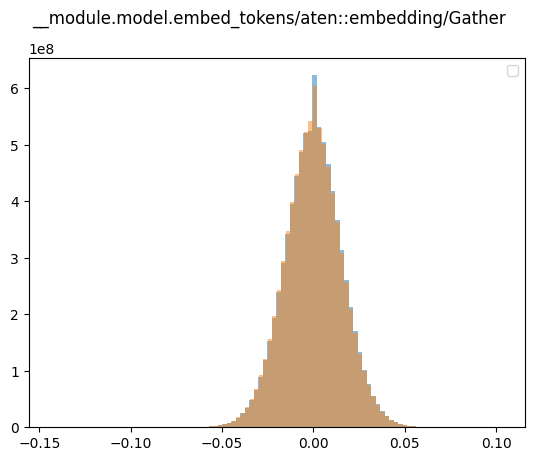

<ipython-input-3-a9c170d53b21>:373: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(
<ipython-input-3-a9c170d53b21>:384: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax3.errorbar(


REG Name __module.model.embed_tokens/aten::embedding/Gather out


In [ ]:
model_fp = "/home/nlyaly/projects/nncf/tests/post_training/tmp/fp32_models/TinyLlama__TinyLlama_v1.1"
model_int = "/home/nlyaly/projects/nncf/tests/post_training/tmp/tinyllama_int8_data_free_full_int8/TORCH"
model_int_ign_emb = "/home/nlyaly/projects/nncf/tests/post_training/tmp/tinyllama_int8_data_free_ign_emb/TORCH"
tokenizer = "TinyLlama/TinyLlama_v1.1"
n_samples = 128
draw_activations_2(
    model_name_fp=model_fp,
    model_name_int=model_int,
    tokenizer_name=tokenizer,
    n_samples=n_samples,
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Prepare the data
# Create sample data for the x, y, and z axes.
# 'Token' and 'Channel' can be thought of as grid coordinates.
tokens = np.arange(200)
channels = np.arange(125)

# Create a meshgrid to represent every point on the x-y plane.
T, C = np.meshgrid(tokens, channels)

# Generate Z values (the height of the surface).
# We'll use a combination of functions to create a varied surface similar
# to the one in the image, with some low-frequency blue areas and
# high-frequency, high-amplitude red areas.
Z = np.zeros_like(T, dtype=float)

# Create a base of random noise (the blue part)
Z += np.random.rand(*T.shape) * 2.5

# Add a region of high-frequency, high-amplitude values (the red part)
# This will be active for tokens greater than 50
high_freq_region = T > 50
Z[high_freq_region] = 7.5 + np.random.rand(*T.shape)[high_freq_region] * 5

# Step 2: Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Step 3: Plot the surface
# Use a colormap like 'coolwarm' or 'viridis' to get the color gradient.
# 'coolwarm' (blue-red) is very similar to the image.
# rstride and cstride control how many rows/columns to step over.
# A stride of 1 creates a solid surface.
surf = ax.plot_surface(T, C, Z, cmap='coolwarm', rstride=1, cstride=1)

# Step 4: Customize the plot
ax.set_title('Example 3D Surface Plot', fontsize=16, pad=20)
ax.set_xlabel('Token', fontsize=12)
ax.set_ylabel('Channel', fontsize=12)
ax.set_zlabel('Value', fontsize=12) # You can name the z-axis as needed

# Set the limits to match the example if desired
ax.set_xlim(0, 200)
ax.set_ylim(0, 125)
ax.set_zlim(0, 13)

# Optionally, add a color bar to show the mapping of values to colors
# fig.colorbar(surf, shrink=0.5, aspect=5)

# Step 5: Display the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Prepare the data
# Create sample data for the x, y, and z axes.
# 'Token' and 'Channel' can be thought of as grid coordinates.
tokens = np.arange(200)
channels = np.arange(125)

# Create a meshgrid to represent every point on the x-y plane.
T, C = np.meshgrid(tokens, channels)

# Generate Z values (the height of the surface).
# We'll use a combination of functions to create a varied surface similar
# to the one in the image, with some low-frequency blue areas and
# high-frequency, high-amplitude red areas.
Z = np.zeros_like(T, dtype=float)

# Create a base of random noise (the blue part)
Z += np.random.rand(*T.shape) * 2.5

# Add a region of high-frequency, high-amplitude values (the red part)
# This will be active for tokens greater than 50
high_freq_region = T > 50
Z[high_freq_region] = 7.5 + np.random.rand(*T.shape)[high_freq_region] * 5

# Step 2: Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Step 3: Plot the surface
# Use a colormap like 'coolwarm' or 'viridis' to get the color gradient.
# 'coolwarm' (blue-red) is very similar to the image.
# rstride and cstride control how many rows/columns to step over.
# A stride of 1 creates a solid surface.
surf = ax.plot_surface(T, C, Z, cmap='coolwarm', rstride=1, cstride=1)

# Step 4: Customize the plot
ax.set_title('Example 3D Surface Plot', fontsize=16, pad=20)
ax.set_xlabel('Token', fontsize=12)
ax.set_ylabel('Channel', fontsize=12)
ax.set_zlabel('Value', fontsize=12) # You can name the z-axis as needed

# Set the limits to match the example if desired
ax.set_xlim(0, 200)
ax.set_ylim(0, 125)
ax.set_zlim(0, 13)

# Optionally, add a color bar to show the mapping of values to colors
# fig.colorbar(surf, shrink=0.5, aspect=5)

# Step 5: Display the plot
plt.show()